# Electronic Products E-Commerce Purchase Classification Analysis

Name: Jay Jung, Namrata Elamaran, Vaidehi Som

### Introduction and Background

#### Problem Statement and Objective
In today's rapidly evolving digital landscape, understanding customer behavior, especially in the electronics market, is crucial for businesses aiming to optimize their sales strategies. Our project focuses on analyzing key factors that influence customer purchase decisions within the electronics sector. By integrating insights from comprehensive datasets, we aim to uncover patterns and drivers that lead to purchases, providing valuable information for businesses to enhance their marketing and sales tactics.

#### Value Proposition
The insights derived from our analysis offer significant value to businesses in the electronics industry. By identifying the main factors driving customer purchases, companies can tailor their marketing strategies to better target potential customers, thereby enhancing customer engagement and optimizing conversion rates. This strategic alignment not only boosts sales but also enhances customer satisfaction by delivering products that meet their expectations and preferences.


### Project Steps

#### Data Loading and Pre-Processing
We began by loading each dataset separately, examining the structure, and identifying inconsistencies. The preprocessing steps included handling missing values, cleaning data, removing irrelevant columns, and ensuring consistency across data types.

#### Data Merging
Our datasets were merged based on common attributes to create a comprehensive view that integrates customer interactions with company metrics. This unified dataset is pivotal for cross-analysis and deriving multi-faceted insights.

#### Pre-Processing the Merged DataFrame
After merging, the data was further processed to reduce granularity to a user-product level, focusing on unique interactions per user per product. This step is crucial for accurate feature representation and subsequent modeling.

#### Exploratory Data Analysis and Feature Engineering
In-depth EDA was conducted to understand data distribution, relationships, and potential trends. New features were engineered from existing data to enhance the model's predictive capability, such as encoded categorical variables and interaction terms.

#### Feature Selection
We utilized correlation matrices to identify and eliminate highly correlated features, reducing multicollinearity and enhancing model performance.

#### Machine Learning
Finally, we applied various machine learning techniques to predict customer purchase behavior. This step involved building, tuning, and training predictive models to accurately classify customer actions and potentially forecast future buying patterns.

### Imports:

Let's start off by importing the packages we need for the project. 

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import regex as re
import seaborn as sns
import os
import pandasql as ps
import folium
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score, f1_score, roc_curve, auc
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from pandasql import sqldf
from geopy.geocoders import Nominatim
from folium.plugins import HeatMap
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import RandomOverSampler

# Reading Datasets, Preprocessing

#### Overview of the Dataset
Our analysis leverages two detailed datasets from Kaggle:
1. **eCommerce Dataset**: This dataset provides a granular view of customer interactions with electronic products, including event types (views, carts, purchases), product categories, brands, and pricing details.
2. **Companies Dataset**: This dataset offers insights into the companies offering these products, including attributes like company name/brand, industry classification, company size, year founded, and the country of origin.

These datasets together form a robust foundation for analyzing customer purchasing behavior and company performance within the electronics market.


### Links to our dataset:
Ecommerce Behavior Data from Multi Category Store (Dataset 1 ): https://www.kaggle.com/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store

7+ Million Company Dataset (Dataset 2): https://www.kaggle.com/datasets/peopledatalabssf/free-7-million-company-dataset

### Dataset 1:

**Pre-processing eCommerce Dataset**

Load the dataset

In [100]:
# Load the dataset 
oct_2019_df = pd.read_csv("2019-Oct.csv")

In [101]:
oct_2019_df.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


Let's understand each of the columns in the dataset: 

1. **event_time**: This column represents the timestamp of each interaction recorded in the dataset. It indicates the time when a particular event, such as viewing, carting, or purchasing a product, occurred.

2. **event_type**: This column denotes the type of event associated with each interaction. It could include events like 'view', 'cart', or 'purchase', indicating whether a user viewed a product, added it to their cart, or made a purchase.

3. **product_id**: This column contains the unique identifier (ID) assigned to each product in the dataset. It allows us to track the specific products that users interact with during their sessions.

4. **category_id**: This column stores the category ID associated with each product. It helps categorize products into different groups or types based on their characteristics or attributes.

5. **brand**: This column provides information about the brand or company that sells the product. It identifies the entity responsible for manufacturing or distributing the item.

6. **user_id**: This column contains the unique identifier assigned to each user in the dataset. It allows us to track the activities and interactions of individual users across different sessions.

7. **user_session**: This column serves as a unique identifier for each user session. It helps group together interactions that occur during the same session, providing insights into user behavior within specific timeframes.

These columns collectively provide valuable information about user-product interactions, enabling analysis and prediction of purchase behavior in the context of electronic commerce.

After loading the dataset, we are dropping the duplicate rows to get rid of redundant information as this could affect our EDA and model downstream

In [102]:
# Dropping duplicates
oct_2019_df = oct_2019_df.drop_duplicates()
# Resetting the index after dropping the rows 
oct_2019_df.reset_index(drop = True, inplace = True)

We are dropping user_session column since it is a unique identifier for each customer's eCommerce activity - and it may not be very useful in analyzing whether a customer makes a purchase or not.

In [103]:
oct_2019_df = oct_2019_df.drop('user_session', axis = 1)
oct_2019_df.reset_index(drop = True, inplace = True)

We are opting to drop the 'category_id' column from our dataset. While it provides a numerical representation of product categories, we find the 'category_code' column to be more intuitive and informative for our analysis. By leveraging 'category_code', we gain a clearer understanding of the product categories, enhancing the interpretability of our results.

Furthermore, by reducing the dimensionality of our dataset and focusing on the more intuitive 'category_code', we effectively streamline our analysis. This approach helps us maintain a manageable search space and facilitates more efficient data exploration and modeling processes. Ultimately, prioritizing 'category_code' aligns with our goal of maximizing the relevance and utility of our dataset for our specific analytical objectives.

In [104]:
oct_2019_df = oct_2019_df.drop('category_id', axis = 1)

Next, we are going to analyze the data types of each column. 

In [105]:
oct_2019_df.dtypes

event_time        object
event_type        object
product_id         int64
category_code     object
brand             object
price            float64
user_id            int64
dtype: object

Upon first glance, it may seem like we need to change the type of 'event_time' to a datetime format. However, since we are not doing any time series analysis, we are not going to be using this column and will be dropping it.

In [106]:
oct_2019_df.drop('event_time', axis = 1, inplace = True)

Let's now try to see if/which columns have missing values in this dataset:

In [107]:
# Checking the columns that have nulls
oct_2019_df.isna().sum() 

event_type              0
product_id              0
category_code    13512262
brand             6116198
price                   0
user_id                 0
dtype: int64

We see that category_code and brand have missing values denoted as NAs. 

Dropping the null values in the 'category_code' and 'brand' columns is essential for our analysis due to the specific requirements of our project. Imputing null values in these columns would not be appropriate because:
1. **Merging Requirement**: We plan to merge datasets based on the 'brand' column. Null values in this column would disrupt the merging process and imputing could potentially lead to inaccuracies in our analysis.
2. **Product Categorization**: We intend to filter the dataset to include only electronic products based on the 'category_code' column. Similar to what's discussed above, imputing null values here would compromise the accuracy of our analysis, as it could result in incorrect categorization of products.

Therefore, dropping null values ensures data integrity and reliability for our analysis, aligning with the specific requirements and objectives of our project.

In [108]:
oct_2019_df = oct_2019_df.dropna()

Now, let us take a look at the distribution of the price:

We only analyze the distribution of the price and not of the other columns because price is the only numerical variable. 

In [109]:
oct_2019_df['price'].describe() 

count    2.653411e+07
mean     3.528803e+02
std      3.811349e+02
min      8.800000e-01
25%      1.081100e+02
50%      2.185100e+02
75%      4.591600e+02
max      2.574070e+03
Name: price, dtype: float64

We see that the minimum price is $0.88 while the maximum price is $2,574.07 - so there is there a diverse range of products in different price ranges.

Next, let us try to analyze the 'category_code' column:

Because we are only interested in electronics products, we need to filter the dataset to include only electronics. 

However, in order to determine whether a product is an electronics, we need to look at the category_code. 

Below, we show you an example of electronics category_code. We see that the category_code has a pattern to have the main category as first set of strings prior to the first period and then subcategories afterwards

In [110]:
electronics_category_example = oct_2019_df[oct_2019_df['category_code'].str.startswith('electronics')]
electronics_category_example = list(electronics_category_example['category_code'][:5].unique())
electronics_category_example

['electronics.smartphone', 'electronics.video.tv']

In order to create a way to filter only electronics product, we will create a column called master_category that will only extract the strings prior to the first period. 

In [111]:
# Extract the master category
def get_master_category(category_code):

    # Input: category_code string 
    # Output: main category stored in master_category column

    # Ensure the category_code is a string before splitting
    master_category = str(category_code).split('.')[0]
    return master_category

# Apply the get_master_category function on category_code column
oct_2019_df['master_category'] = oct_2019_df['category_code'].apply(get_master_category)

Let us see the distribution of main categories in this dataset:

In [112]:
oct_2019_df['master_category'].value_counts()

master_category
electronics     15816887
appliances       4658043
computers        2253332
apparel          1130978
auto              768956
construction      549136
furniture         539243
kids              423442
accessories       207668
sport             152965
medicine           14167
country_yard       13461
stationery          5833
Name: count, dtype: int64

Our analysis reveals a notable prevalence of electronics products within e-commerce activities compared to other product categories. Consumers demonstrate a higher propensity to engage with electronics products, including viewing, carting, or purchasing them, indicating a significant interest and demand in this segment.

Given this observation, we recognize the importance of focusing our model exclusively on electronic products. By honing in on this specific category, we aim to optimize the accuracy and reliability of our predictive model. This strategic decision acknowledges that feature importances may vary across different product categories. By narrowing our scope to electronics products, we can better capture the relevant patterns and relationships specific to this high-engagement category, thereby enhancing the effectiveness of our model for predicting purchase behavior.

In [113]:
electronics_df = oct_2019_df[oct_2019_df['master_category'] == 'electronics'] # Filtering for electronics

Now, since we have filtered for only electronics, we can now drop the 'master_category'. 

In [114]:
electronics_df = electronics_df.drop('master_category', axis = 1)

In [115]:
print(f"The shape of the reduced, cleaned df is {electronics_df.shape}")

The shape of the reduced, cleaned df is (15816887, 6)


Here, we have completed the necessary pre-processing of the ecommerce activites data before merging with the companies dataset. This is now ready to be merged.

### Dataset 2:

**Pre-processing Companies Dataset**

Load the companies dataset

In [116]:
companies_df = pd.read_csv("companies_sorted.csv")

Let's look at our dataset

In [117]:
companies_df.head(5)

,Unnamed: 0,name,domain,year founded,industry,size range,locality,country,linkedin url,current employee estimate,total employee estimate
0,5872184,ibm,ibm.com,1911.0,information technology and services,10001+,"new york, new york, united states",united states,linkedin.com/company/ibm,274047,716906
1,4425416,tata consultancy services,tcs.com,1968.0,information technology and services,10001+,"bombay, maharashtra, india",india,linkedin.com/company/tata-consultancy-services,190771,341369
2,21074,accenture,accenture.com,1989.0,information technology and services,10001+,"dublin, dublin, ireland",ireland,linkedin.com/company/accenture,190689,455768
3,2309813,us army,goarmy.com,1800.0,military,10001+,"alexandria, virginia, united states",united states,linkedin.com/company/us-army,162163,445958
4,1558607,ey,ey.com,1989.0,accounting,10001+,"london, greater london, united kingdom",united kingdom,linkedin.com/company/ernstandyoung,158363,428960


The dataframe consists of various columns providing information about different companies. These include:

1. **Name**: The name of the company.
2. **Domain**: The website associated with the company.
3. **Year Founded**: The year in which the company was established.
4. **Industry**: The industry to which the company belongs.
5. **Size Range**: A range indicating the number of employees working at the company.
6. **Locality**: The geographical location of the company's headquarters.
7. **Country**: The country in which the company is located.
8. **LinkedIn URL**: The URL linking to the company's LinkedIn page.
9. **Current Employee Estimate**: An estimate of the current number of employees at the company.
10. **Total Employee Estimate**: An estimate of the total number of employees employed by the company.

In [118]:
companies_df.shape

(7173426, 11)

In this current dataset, we have information of more than 7.1 million companies

We also display the datatype of each column, as we have for the other dataframe. 

In [119]:
companies_df.dtypes

Unnamed: 0                     int64
name                          object
domain                        object
year founded                 float64
industry                      object
size range                    object
locality                      object
country                       object
linkedin url                  object
current employee estimate      int64
total employee estimate        int64
dtype: object

We have decided to drop several columns from our dataset for various reasons:

1. **Unnamed Column**: This column is likely an indexing column that was not removed by the data provider. It does not provide any relevant information for our analysis and thus will be dropped.
2. **LinkedIn URL**: We have opted to drop this column as we do not intend to utilize it for either data cleaning or analysis purposes.
3. **Current Employee Estimate and Total Employee Estimate**: We will be dropping these columns as the information they provide is likely already encompassed in the "Size Range" column, which we will use for our analysis.
4. **Locality**: We have decided to drop the "Locality" column in favor of using the "Country" column for our analysis, as it provides a more comprehensive geographic feature.

These decisions are aimed at streamlining our dataset and focusing on the most relevant features for our analysis.

In [120]:
companies_df = companies_df.drop("Unnamed: 0", axis = 1)
companies_df = companies_df.drop("linkedin url", axis = 1)
companies_df = companies_df.drop('current employee estimate', axis = 1)
companies_df = companies_df.drop('total employee estimate', axis = 1)
companies_df = companies_df.drop('locality', axis = 1)

We will drop the duplicate rows to ensure each row is unique

In [121]:
companies_df = companies_df.drop_duplicates()
companies_df = companies_df.reset_index(drop = True)

Now, we will look at which columns the dataset has missing values:

In [122]:
companies_df.isna().sum()

name                  3
domain          1649358
year founded    3605747
industry         289806
size range            0
country         2348249
dtype: int64

We see that we have NAs for name, domain, year founded, industry, and country.

We will handle the NAs in the country column by replacing NAs with "Unknown". 

This ensures that we maintain as many companies as possible in our data and allow us to know that we do not know the country of origin for those companies. We will be encoding for countries later, and therefore need to have a non-null value for country.

In [123]:
companies_df['country'] = companies_df['country'].fillna("Unknown")

To handle missing values in the 'year founded' variable, we will create an indicator column named 'is_yearfounded_null'. This column will serve as a binary indicator: it will be set to 1 if the year founded is missing for a particular company, and 0 otherwise. By doing so, we can easily identify companies with unknown founding years in our dataset.

To ensure the integrity of the indicator column, we will replace any missing values in the 'year founded' variable with zeros. This approach allows us to effectively capture and account for instances where the founding year information is unavailable.

In [124]:
# Create a new column 'is_yearfounded_null' indicating null values
companies_df['is_yearfounded_null'] = companies_df['year founded'].isnull().astype(int)

# Impute null values in 'year founded' column with 0
companies_df['year founded'].fillna(0, inplace=True)

/var/folders/p6/wmyhr91j07x0g9h2lglh__jh0000gn/T/ipykernel_23885/386723939.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  companies_df['year founded'].fillna(0, inplace=True)


We've effectively addressed missing values for the 'country' and 'year founded' columns.

To ensure data integrity, we'll drop rows where the 'name' column is missing, as it's crucial for merging with the ecommerce activity dataset.

Similarly, rows with missing values in the 'domain' column will be dropped to facilitate downstream filtering tasks that rely on this information.

Additionally, we'll exclude rows with missing values in the 'industry' column, as our analysis focuses specifically on companies within electronics-related industries. Retaining only complete data in this column ensures we accurately identify companies relevant to our analysis.

Now that we have handled all the NAs in the columns we are interested in, we can drop the NAs in the rest of the columns (i.e., domain, name and industry) as justified above:

In [125]:
companies_df = companies_df.dropna()

As a part of data pre-processing, we checked whether there are multiple companies under the same name. 

With the example of Google, we see that it is indeed possible. 

In [126]:
companies_df[companies_df['name'] == 'google']

,name,domain,year founded,industry,size range,country,is_yearfounded_null
28,google,google.com,1998.0,internet,10001+,united states,0
939214,google,legacy.ventures,2015.0,non-profit organization management,11 - 50,australia,0
5043264,google,servicemaxusa.com,1991.0,consumer services,1 - 10,united states,0


This may have happened due to data entry error or could be that the other companies are acquired companies. To only include the company that will be the most relevant, we will drop the rows where `name` is not in the `domain` column. 

In [127]:
# regex pattern to create domain extracted 
pattern_company = r'(.+)\.' # At least 1 and as many as possible
companies_df['domain_extracted'] = companies_df['domain'].str.extract(pattern_company)

# Dropping duplicate companies using the regex pattern 

# Extract the list of companies that are duplicated
duplicated_companies = companies_df[companies_df['name'].map(companies_df['name'].value_counts()) > 1] 

# Extract the list of companies that are not duplicated
non_duplicated_companies = companies_df[companies_df['name'].map(companies_df['name'].value_counts()) ==  1]

# Keeping the companies where name is the same as the domain extracted using the regex pattern
fixed_duplicated_companies = duplicated_companies[duplicated_companies['name']== duplicated_companies['domain_extracted']]

# Append the non-duplicated companies with the newly extracted dataframe without duplicates
new_companies_df = pd.concat([fixed_duplicated_companies, non_duplicated_companies], axis = 0)

# Resetting index
new_companies_df.reset_index(inplace = True, drop = True)

Even after trying to find the company with names in the domain, we see that there are still duplicates. 

In [128]:
# Get the list of companies that are still duplicated - duplicates stemmed from the name of company being the same as domain extracted
dup = new_companies_df['name'].value_counts().reset_index()
dup = dup[dup['count']>1]
dup_companies = list(dup['name'])

# Printing the list of companies that are still duplicated
dup_companies

['indigo',
 'elevate',
 'sphere',
 'citynet',
 'hustle',
 'adcom',
 'square',
 'e-volution',
 'microtech',
 'quantum',
 'infomedia',
 'neos',
 'lucid',
 'idea',
 'factor',
 'merx',
 'standout',
 'morphosis',
 'canopy',
 'illuminate',
 'presence',
 'zinc',
 'ditto',
 'hatch',
 'runa',
 'whitespace',
 'creasoft',
 'rtp',
 'modis',
 'atrium',
 'cnx',
 'samsys',
 'substance',
 'forta',
 'ampersand',
 'totem',
 'braintrust',
 'mybrand',
 'ims',
 'creativeiq',
 'formulate',
 'aptiv',
 'weventure',
 'playr',
 'connector',
 'percipio',
 'icono',
 'auctus',
 'koda',
 'netmedia',
 'refresh',
 'keycode',
 'citec',
 'smac',
 'bloombox',
 'stackforce',
 'assure',
 'hash',
 'inventis',
 'jiminy',
 'idss',
 'negocia',
 'onward',
 'unify',
 'vivacity',
 'imas',
 'circl',
 'nosco',
 'dynamo',
 'navitas',
 'untapped',
 'envision',
 'privy',
 'ledcom',
 'elium',
 'alive',
 'alinea',
 'brandworks',
 'interface',
 'buildify',
 'reach',
 'powerhouse',
 'servitium',
 'zentec',
 'indeo',
 'cheers',
 'haystack

To ensure that we have unique name of companies in the dataset, we will drop those companies

In [129]:
# Dropping duplicates
new_companies_df = new_companies_df[~new_companies_df['name'].isin(dup_companies)]

We will now filter the companies dataset to include only those with electronics-related industries.

In order to do so, we took a look at the top 50 industries in the dataset -- and we found the following industries that are electronics-related and oriented towards consumers: 
* 'telecommunications', 'entertainment', 'internet', 'computer software', 'health, wellness and fitness', 'information technology and services', 'music'

The below list shows the top 50 industries

In [130]:
list_industry = new_companies_df['industry'].value_counts().reset_index()
list(list_industry['industry'])[:50]

['information technology and services',
 'marketing and advertising',
 'construction',
 'management consulting',
 'real estate',
 'computer software',
 'internet',
 'financial services',
 'health, wellness and fitness',
 'education management',
 'design',
 'hospital & health care',
 'retail',
 'non-profit organization management',
 'automotive',
 'hospitality',
 'food & beverages',
 'professional training & coaching',
 'entertainment',
 'law practice',
 'accounting',
 'events services',
 'staffing and recruiting',
 'architecture & planning',
 'mechanical or industrial engineering',
 'human resources',
 'leisure, travel & tourism',
 'media production',
 'telecommunications',
 'electrical/electronic manufacturing',
 'insurance',
 'oil & energy',
 'sports',
 'apparel & fashion',
 'legal services',
 'environmental services',
 'consumer services',
 'transportation/trucking/railroad',
 'machinery',
 'music',
 'renewables & environment',
 'consumer goods',
 'photography',
 'graphic design',
 

We will filter the data to include companies from the listed industries only

In [131]:
industry_ls = ['telecommunications', 'entertainment', 'internet', 'computer software', 'health, wellness and fitness','information technology and services', 'music']
new_companies_df = new_companies_df[new_companies_df['industry'].isin(industry_ls)]

Now that we have done pre-processing, we can drop the column `domain_extracted` and `domain` that was utilized to filter the companies but not utilized for analyses. 

In [132]:
new_companies_df = new_companies_df.drop(columns=['domain_extracted', 'domain'])

This dataset is now ready to be merged!

In [133]:
new_companies_df.head(5)

,name,year founded,industry,size range,country,is_yearfounded_null
0,ibm,1911.0,information technology and services,10001+,united states,0
1,accenture,1989.0,information technology and services,10001+,ireland,0
2,microsoft,1975.0,computer software,10001+,united states,0
6,oracle,1977.0,information technology and services,10001+,united states,0
7,capgemini,1967.0,information technology and services,10001+,france,0


In [134]:
print(f"The size of this cleaned, pre-processed dataset is {new_companies_df.shape}")

The size of this cleaned, pre-processed dataset is (929604, 6)


# Merging

**Pre-processing: Joining the Two Dataframes using pandas sql**

In [38]:
join_query = '''
SELECT * 
FROM new_companies_df JOIN electronics_df on new_companies_df.name = electronics_df.brand
'''

df_merged_sql = ps.sqldf(join_query, locals())

In [39]:
df_merged_sql.head(5)

,name,year founded,industry,size range,country,is_yearfounded_null,event_time,event_type,product_id,category_id,category_code,brand,price,user_id
0,microsoft,1975.0,computer software,10001+,united states,0,2019-10-01 02:19:10.000000,view,1201432,2172371436436455782,electronics.tablet,microsoft,1029.37,515581296
1,microsoft,1975.0,computer software,10001+,united states,0,2019-10-01 02:55:23.000000,view,1201517,2172371436436455782,electronics.tablet,microsoft,1104.28,527998368
2,microsoft,1975.0,computer software,10001+,united states,0,2019-10-01 03:02:47.000000,view,1201432,2172371436436455782,electronics.tablet,microsoft,1029.37,555467529
3,microsoft,1975.0,computer software,10001+,united states,0,2019-10-01 03:03:19.000000,view,1201432,2172371436436455782,electronics.tablet,microsoft,1029.37,555467529
4,microsoft,1975.0,computer software,10001+,united states,0,2019-10-01 03:08:20.000000,view,1201232,2053013561059312345,electronics.tablet,microsoft,900.67,526157835


Export the data as a way to ensure the data is not lost during the computation.

In [ ]:
df_merged_sql.to_csv("ecommerce_company_merged.csv", index=False)

The new merged dataframe has around 3.69 million rows

In [41]:
df_merged_sql.shape

(3694572, 14)

# Processing

To avoid re-running all of the code above each time, we saved the merged df and used that for the rest of our analysis

In [135]:
df_merged = pd.read_csv("ecommerce_company_merged.csv")

**Pre-processing and Feature Engineering on the Merged Dataframe**

We start by transforming the dataframe to reduce it such that each row represents a unique combination of product_id and user_id. This consolidation allows us to focus on individual user-product interactions. Subsequently, we augment the dataset by including features indicating the total number of times a user visited, carted, and purchased a specific product at a given price. These additional features capture user engagement and behavior patterns related to the product. Our objective is to leverage this enriched dataset to predict whether a customer will make a purchase utilizing the frequency of user visits and cart interactions as two of the predictive indicators.

In [136]:
# create a copy of the merged dataset and filter to include only user_id, product_id, price, and event_type 
user_metric = df_merged.copy()
user_metric = user_metric[['user_id', 'product_id', 'price', 'event_type']]

# performing encoding of event_type
user_metric = user_metric.copy()
user_metric['view'] = np.where(user_metric['event_type']=="view", 1, 0)
user_metric['cart'] = np.where(user_metric['event_type']=="cart", 1, 0)
user_metric['purchase'] = np.where(user_metric['event_type']=="purchase", 1, 0)

# after encoding, drop the event_type column
user_metric = user_metric.drop(columns=['event_type'])

In [137]:
# perform aggregation of the dataframe by grouping on user_id, product_id, and price to calculate the total number of visits, carts, and purchases
user_metric = user_metric.groupby(by=['user_id', 'product_id', 'price']).agg(
    total_views=('view', 'sum'),
    total_carts=('cart', 'sum'),
    total_purchases=('purchase', 'sum')
).reset_index()

In [138]:
# merge the user_metric data with the main dataframe on user_id, product_id, and price
df_merged_fin = pd.merge(user_metric, df_merged, on=['user_id', 'product_id', 'price'])

# NEED to drop event_type also here since we already accounted for that in the groupby
df_merged_fin = df_merged_fin.drop(columns =['event_type'])

# NEED to drop 'name' since name and brand convey the same information and one of the columns are enough for the analysis: merge was performed on name = brand
df_merged_fin = df_merged_fin.drop(columns =['name'])

# because we are interested only at the 'user_id', 'product_id', 'price', drop duplicate rows with the same  'user_id', 'product_id', 'price', 'total_views', 'total_carts', and 'total_purchases' combination 
df_merged_fin = df_merged_fin.drop_duplicates(['user_id', 'product_id', 'price', 'total_views', 'total_carts', 'total_purchases'])

# create an indicator for whether a user purchased a given product at a given price if number of purchases is greater than 0 
df_merged_fin['purchased'] = np.where(df_merged_fin['total_purchases']>0, 1, 0)

This is now our final dataframe - which is ready for EDA!

In [139]:
df_merged_fin

,user_id,product_id,price,total_views,total_carts,total_purchases,year founded,industry,size range,country,is_yearfounded_null,event_time,category_id,category_code,brand,purchased
0,224520397,8800028,43.50,1,0,0,0.0,information technology and services,1 - 10,united states,1,2019-10-26 04:14:55.000000,2053013555573162395,electronics.telephone,texet,0
1,239475080,11300053,17.45,1,0,0,0.0,information technology and services,1 - 10,united states,1,2019-10-05 18:20:26.000000,2053013555531219353,electronics.telephone,texet,0
2,239876607,1004777,135.01,2,0,0,2010.0,internet,51 - 200,china,0,2019-10-09 09:46:02.000000,2053013555631882655,electronics.smartphone,xiaomi,0
4,239876607,1004886,153.88,1,0,0,0.0,telecommunications,5001 - 10000,china,1,2019-10-09 06:36:13.000000,2053013555631882655,electronics.smartphone,oppo,0
5,239876607,1004956,375.79,4,0,0,2010.0,internet,51 - 200,china,0,2019-10-09 06:33:01.000000,2053013555631882655,electronics.smartphone,xiaomi,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3694563,566276537,14300207,333.83,2,0,0,1960.0,music,1001 - 5000,united states,0,2019-10-31 23:26:08.000000,2053013557603205653,electronics.audio.music_tools.piano,yamaha,0
3694565,566277911,1004839,179.12,1,0,0,0.0,telecommunications,5001 - 10000,china,1,2019-10-31 23:41:55.000000,2053013555631882655,electronics.smartphone,oppo,0
3694566,566278181,1004886,128.68,2,0,0,0.0,telecommunications,5001 - 10000,china,1,2019-10-31 23:36:28.000000,2053013555631882655,electronics.smartphone,oppo,0
3694568,566278181,1005008,94.46,2,0,0,2010.0,internet,51 - 200,china,0,2019-10-31 23:35:26.000000,2053013555631882655,electronics.smartphone,xiaomi,0


This dataframe has around 1.9 million rows

# EDA and Feature Engineering

Let us now plot some graphs and charts to do exploratory data analysis on this dataframe that we have

### EDA 1: Price distribution by Category code and by Industry:

Box Plot of Prices by Subcategory:

**Purpose of this plot**
* To graphically represent the price distribution across various subcategories of electronic products

<Figure size 1200x800 with 0 Axes>

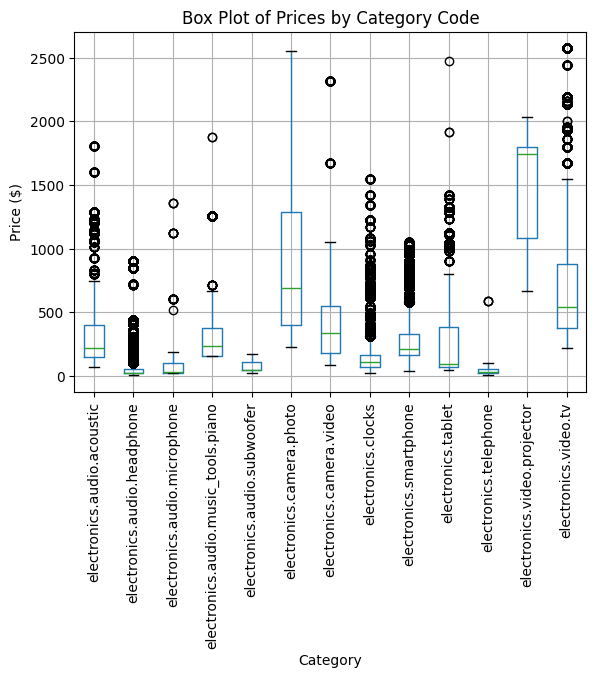

In [140]:
# Creating the box plot

# Reduce the data frame here to product level 
df_unique_product_id = df_merged_fin[['product_id','price', 'category_code']]
df_unique_product_id.drop_duplicates()

plt.figure(figsize=(12, 8))
df_unique_product_id.boxplot(column='price', by='category_code', rot=90)
plt.title('Box Plot of Prices by Category Code')
plt.suptitle('') 
plt.xlabel('Category')
plt.ylabel('Price ($)')
plt.show()

**Takeaway:**

* A clear takeaway is the substantial price variability within each subcategory, indicative of a diverse market offering a range of product qualities and features. Because of the variability in the price distribution across different subcategories, we believe it would be necessary to include this in our analysis as this may affect the rate of purchase. 

* The occurrence of outliers reflects the expected price stratification inherent in the electronics sector. Here, premium prices can be justified by advanced technology and the esteemed reputation of certain brands. Consequently, these outliers are indicative of a real-world pricing structure, and their retention in the price dataset is crucial. By preserving these data points, we acknowledge that the wide price variation across different product subcategories is a significant factor influencing purchasing decisions. This approach allows us to maintain the integrity of the data, ensuring that our analysis accurately captures the impact of price on consumer behavior.

**Feature engineering: One-hot encoding for category column**

Let us now perform encoding for the category code column, which we will be used for machine learning

While we only included products that belong to the electronics category, we want to incorporate the subcategories of electronics that the E-Commerce Activity dataset provides into our analysis. It is because it is possible that customers are more likely to purchase items online if the item is of certain subcategory. 

Below, we show the subcategories of electronics we have. 

In [141]:
df_merged_fin['category_code'].unique()

array(['electronics.telephone', 'electronics.smartphone',
       'electronics.audio.acoustic', 'electronics.video.tv',
       'electronics.tablet', 'electronics.audio.headphone',
       'electronics.clocks', 'electronics.audio.subwoofer',
       'electronics.audio.music_tools.piano', 'electronics.camera.video',
       'electronics.camera.photo', 'electronics.video.projector',
       'electronics.audio.microphone'], dtype=object)

Because the variable conveying the subcategory of electronics is a categorical variable, we want to encode them by creating dummy columns for each of the subcategories. 

In [142]:
# Create a copy of df_merged_fin to perform 
one_hot = df_merged_fin.copy()

one_hot['category_code'] = one_hot['category_code'].astype('category')
one_hot = pd.get_dummies(one_hot[['category_code']], drop_first = True)
one_hot = one_hot.astype(int)
df_merged_fin = pd.concat([df_merged_fin, one_hot], axis = 1)

**EDA for Industries:**

**Purpose of this plot**
* To illustrate the distribution of prices across different industries, offering insights into the variability and potential outliers within each sector.

<Figure size 1200x800 with 0 Axes>

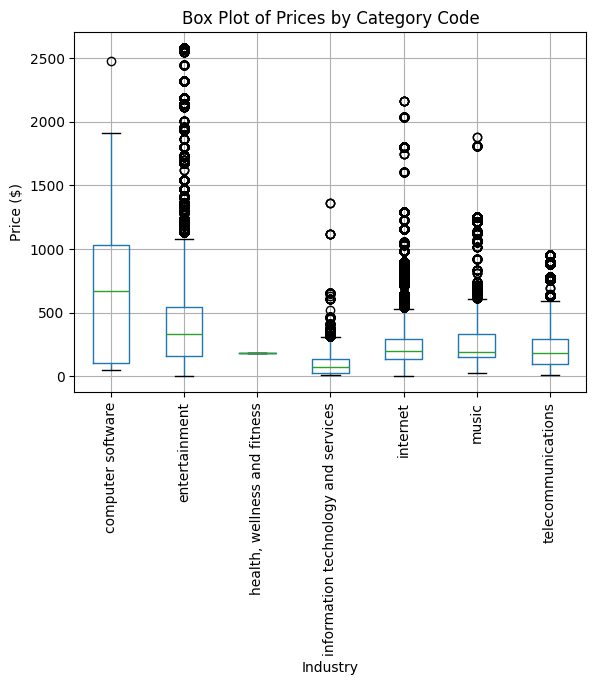

In [143]:
# Reduce the data frame here to product level 
df_unique_product_id = df_merged_fin[['product_id','price', 'industry']]
df_unique_product_id.drop_duplicates()

plt.figure(figsize=(12, 8))
df_unique_product_id.boxplot(column='price', by='industry', rot=90)
plt.title('Box Plot of Prices by Category Code')
plt.suptitle('') 
plt.xlabel('Industry')
plt.ylabel('Price ($)')
plt.show()

**Takeaway:**

* In this box plot, industries such as 'health, wellness, and fitness' and 'computer software' exhibit minimal outliers, suggesting a more concentrated distribution of prices. This observation could stem from the relatively focused nature of products or services within these industries. For instance, 'health, wellness, and fitness' may predominantly offer standardized services or products with consistent pricing tiers, resulting in fewer extreme price points.

* Conversely, industries like 'entertainment' and 'internet' showcase a notable presence of outliers. This phenomenon may be attributed to the inherent diversity within these sectors, encompassing a wide array of products, services, and business models. The 'entertainment' industry, for instance, encompasses various forms of media, live performances, and digital content, each with its unique pricing structure and consumer demand dynamics. Similarly, the 'internet' sector spans e-commerce platforms, digital services, and subscription-based models, contributing to a broader range of price points and a higher likelihood of outliers.

* Since we can see that there are differences in the distribution for each industry, we should consider industry as a feature. Additionally, the outliers will not be dropped here since these are real world data, and not due to any error, but due to the nature of the industry.

**Feature Enginereing: One-hot Encoding for Industries:**

One-hot encoding for industry to make this column more usable for the ML models:

In [144]:
# Create a copy of df_merged_fin to perform 
one_hot = df_merged_fin.copy()

one_hot['industry'] = one_hot['industry'].astype('category')
one_hot = pd.get_dummies(one_hot[['industry']], drop_first = True)
one_hot = one_hot.astype(int)
df_merged_fin = pd.concat([df_merged_fin, one_hot], axis = 1)

### EDA 2: Company size range analysis:

**Purpose:** 
- A bar chart to compare the number of companies or events in each size range.
- This will give you an idea of the company sizes that are most active or most represented in our dataset.

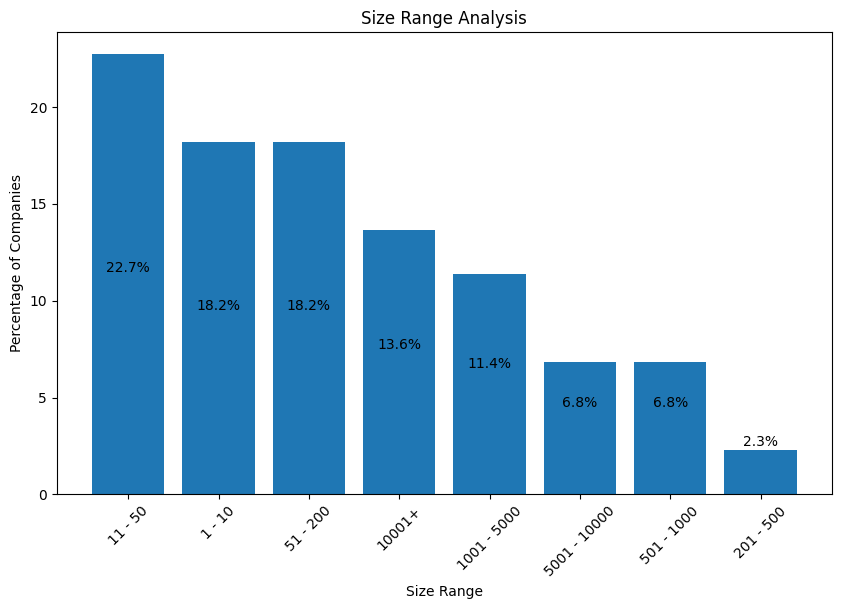

In [145]:
# Assuming df_merged_fin is your DataFrame and contains a 'size range' column.
size_range_counts = df_merged_fin[['brand', 'size range']]
size_range_counts = size_range_counts.drop_duplicates().reset_index(drop=True)

num_companies = len(size_range_counts)
size_range_counts = size_range_counts['size range'].value_counts()

# Create a bar chart to compare the number of events in each size range
plt.figure(figsize=(10, 6))
plt.bar(size_range_counts.index, size_range_counts.values/num_companies*100)
#sns.barplot(x=size_range_counts.index, y=size_range_counts.values/num_companies*100, palette='muted')

for i, value in enumerate(size_range_counts.values):
    plt.text(i, value + 1.5, f'{round(value/num_companies*100, 1)}%', ha='center')

# Label the chart
plt.title('Size Range Analysis')
plt.xlabel('Size Range')
plt.ylabel('Percentage of Companies')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Show the plot
plt.show()

The above bar chart visualizes the distribution of companies by size range within the dataset `df_merged_fin`. The sizes are categorized into ranges, such as '1-10', '11-50', up to '10001+'. Each bar represents the percentage of companies in a particular size category relative to the total number of unique companies in the dataset.

1. **Consumer Behavior Insights**: Different size ranges may correlate with different consumer behaviors. For example, consumers may prefer products from mid-size companies due to perceived reliability, which is less risky than startups but more personalized than large corporations.

2. **Resource Allocation and Marketing Strategies**: Larger companies might have more resources for marketing, which could lead to higher purchase rates. Identifying the company size ranges with higher purchase frequencies can inform targeted marketing and sales strategies.

3. **Product Diversity and Availability**: Larger companies may offer a wider variety of products or have better stock availability, potentially leading to more purchases. Understanding the size range distribution helps predict which companies are likely to contribute more to the overall purchase count.

4. **Trust and Brand Recognition**: Smaller companies in the '1-10' and '11-50' employee range may not have the same level of brand recognition as larger ones. Trust and recognition can significantly influence a consumer's decision to purchase, with well-known brands possibly having higher conversion rates.

5. **Innovation and Market Trends**: The surge in companies founded in recent decades, particularly in the tech industry, may indicate a trend toward innovative products that are in demand. The size range analysis can show if these newer, possibly smaller companies are capturing market share and resulting in purchases.

**Takeaways for Purchase Prediction**:
- The dominant presence of companies in the '11-50' size range could indicate a market sweet spot, where businesses are established enough to be trusted but not too large to be impersonal.
- The significant portion of smaller companies ('1-10' and '51-200') suggests that targeting these groups for predictive analysis could be beneficial, as they represent a substantial segment of the market.
- Lower representation of larger companies ('1001-5000' and '5001-10000') in the dataset implies that while their impact on purchase decisions might be substantial on a per-company basis, there are fewer such companies to analyze.
- The underrepresentation of '201-500' sized companies may require specific attention to understand why this segment has a lower frequency, which could be due to niche markets, specialized products, or other factors not directly related to size.

By analyzing company size distribution with purchase predictions in mind, we can better understand which company segments are more likely to convert views into purchases and tailor our predictive models and business strategies accordingly.

**Feature Engineering - Ordinal Encoding for size-range:**

This categorical variable has an inherent order, and includes ranges between 1-10 to 10000+ As we are interested in analyzing customer purchases using the size range variable, the size range will need to be encoded - but using ordinal encoding. 

In [146]:
# Instantiate the OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[['1 - 10', '11 - 50', '51 - 200', '201 - 500', '501 - 1000', '1001 - 5000', '5001 - 10000', '10001+']])

df_merged_fin_encoded = ordinal_encoder.fit_transform(df_merged_fin[['size range']])

# Assign this back to the DataFrame:
df_merged_fin['size_range_encoded'] = df_merged_fin_encoded

### EDA 3: Top companies sales distribution:

**Purpose**: 

- The bar charts illustrate consumer interactions with products from major electronics companies at three key stages: views, cart additions, and purchases.

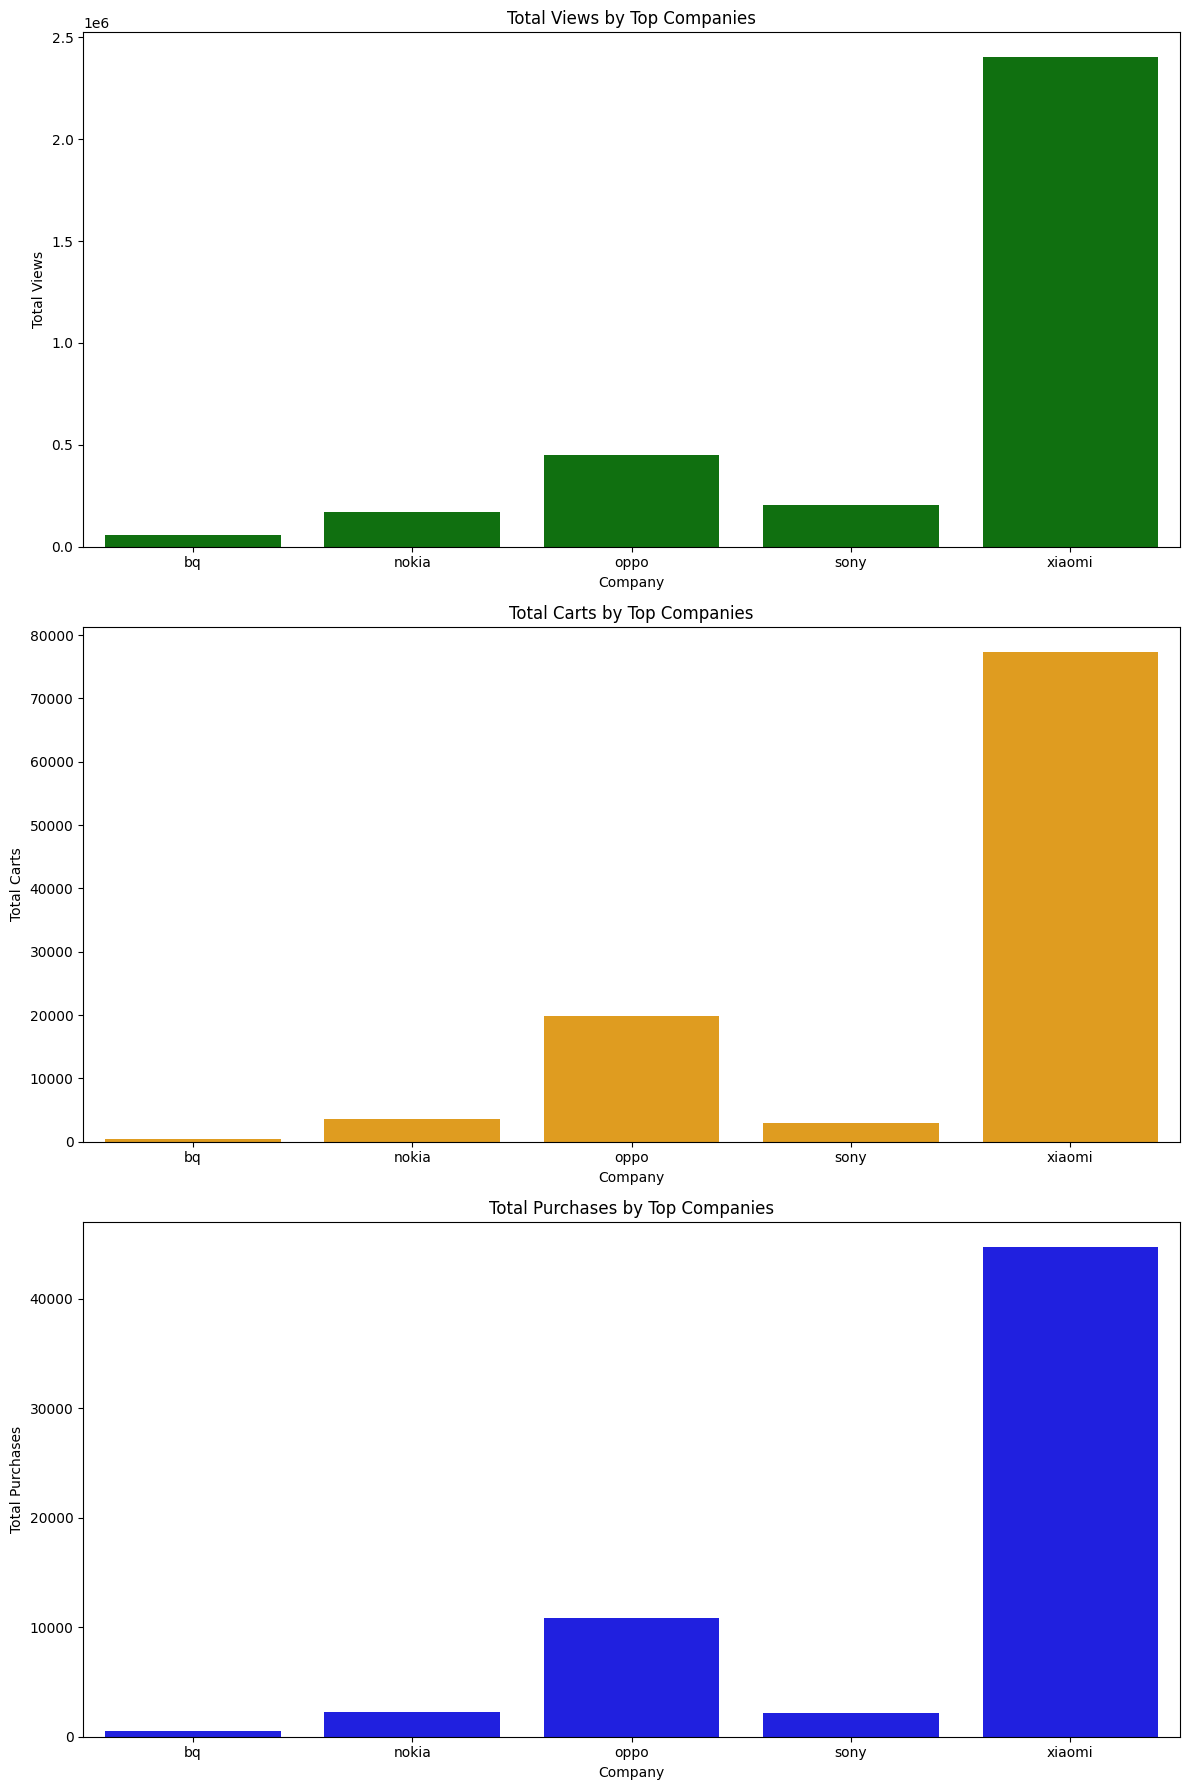

In [147]:
# Get the top 5 companies
top_5_companies = df_merged_fin['brand'].value_counts().head(5).index.tolist()

# Filter the DataFrame for the top 5 companies
df_top_companies = df_merged_fin[df_merged_fin['brand'].isin(top_5_companies)]

# Calculate the total purchases, total carts, and total views for each of the top companies
company_stats = df_top_companies.groupby('brand').agg({'total_purchases': 'sum', 'total_carts': 'sum', 'total_views': 'sum'})

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 18))

# Plot total views
sns.barplot(x=company_stats.index, y=company_stats['total_views'], color='green', ax=axs[0])
axs[0].set_title('Total Views by Top Companies')
axs[0].set_xlabel('Company')
axs[0].set_ylabel('Total Views')

# Plot total carts
sns.barplot(x=company_stats.index, y=company_stats['total_carts'], color='orange', ax=axs[1])
axs[1].set_title('Total Carts by Top Companies')
axs[1].set_xlabel('Company')
axs[1].set_ylabel('Total Carts')

# Plot total purchases
sns.barplot(x=company_stats.index, y=company_stats['total_purchases'], color='blue', ax=axs[2])
axs[2].set_title('Total Purchases by Top Companies')
axs[2].set_xlabel('Company')
axs[2].set_ylabel('Total Purchases')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

**Takeaway:**

Xiaomi leads significantly in product views, which may indicate high customer interest or effective visibility strategies. In stark contrast, BQ and Nokia show minimal activity across all stages, hinting at lower engagement or market presence. 

The fact that the trend of consumers interations do not change across all five major companies may indicate that companies that have higher number of visits would lead to more purchases. Therefore, this may be an indication that companies looking to expand their online market presence should invest more resources to nudge customers to visit and get exposed to their products. 

**Feature Engineering - One-hot encoding for the brand column**

In [148]:
# Get the top 5 companies by frequency
top_5_companies = df_merged_fin['brand'].value_counts().head(5)

# Calculate the total number of companies
total_companies = df_merged_fin['brand'].value_counts().sum()

# Calculate the percentage of total companies covered by the top 5
percentage_covered = (top_5_companies.sum() / total_companies) * 100

print(f"The top 5 companies cover {percentage_covered:.2f}% of the total number of companies, and therefore since that is a significant portion of our data, we will be encoding top 5 only, and put the rest of the companies into an 'others' category")

The top 5 companies cover 92.80% of the total number of companies, and therefore since that is a significant portion of our data, we will be encoding top 5 only, and put the rest of the companies into an 'others' category


In [149]:
# Get the top 5 countries
top_5_companies = df_merged_fin['brand'].value_counts().head(5).index.tolist()

# Replace countries not in the top 5 with 'Other'
df_merged_fin['top_companies'] = df_merged_fin['brand'].apply(lambda x: x if x in top_5_companies else 'Other')

country_count = df_merged_fin['top_companies'].value_counts() 

# Create a copy of df_merged_fin to perform 
one_hot = df_merged_fin.copy()

one_hot['top_companies'] = one_hot['top_companies'].astype('category')
one_hot = pd.get_dummies(one_hot[['top_companies']], drop_first = True)
one_hot = one_hot.astype(int)
df_merged_fin = pd.concat([df_merged_fin, one_hot], axis = 1)

This code snippet performs the following tasks:

1. It identifies the top 5 companies by the frequency of occurrence in the 'brand' column of the DataFrame.
2. It creates a new column 'top_companies' where the brand names not in the top 5 are replaced with 'Other'.
3. It counts the occurrences of each brand in the 'top_companies' column.
4. It creates one-hot encoded dummy variables for the 'top_companies' column, dropping the first category to avoid multicollinearity.
5. Finally, it concatenates the one-hot encoded dummy variables with the original DataFrame.

Overall, this process enables the transformation of the categorical 'brand' column into numerical features suitable for machine learning algorithms, facilitating analysis and prediction tasks.

### EDA 4: Countries distribution using heatmap:

Purpose of this plot: 
* To display the geographical distribution of companies within the dataset using a heatmap of countries of product origin

In [150]:
country_count = df_merged_fin['country'].value_counts().reset_index()

# Initialize geolocator
geolocator = Nominatim(user_agent="company_locator")

# Function to get latitude and longitude for a country
def get_coordinates(country):
    location = geolocator.geocode(country)
    if location:
        return location.latitude, location.longitude
    else:
        return None, None

# Apply function to get coordinates for each country
country_count['latitude'], country_count['longitude'] = zip(*country_count['country'].apply(get_coordinates))

# Create a map centered at a specific location (e.g., the world)
m = folium.Map(location=[30, 0], zoom_start=2)

# Ensure there are no NaN values in the latitude and longitude columns
country_count = country_count.dropna(subset=['latitude', 'longitude'])

# Convert DataFrame to list of tuples (latitude, longitude, weight)
locations = list(zip(country_count['latitude'], country_count['longitude'], country_count['count']))

# Create HeatMap with locations and add it to the map
HeatMap(locations).add_to(m)

# Display the map
m

Takeaway: 
* Notably, a significant concentration of companies is observed in and around China, which aligns with expectations considering the dataset's focus on electronics. China has long been recognized as a global hub for electronics manufacturing, with a robust ecosystem encompassing suppliers, manufacturers, and technology firms.

* This heatmap also highlights the concentration of companies in other regions, with notable concentrations observed in the United States and various European countries.

* It is possible that products from countries such as China, European countries and the United States have a different purchasing pattern compared to some of the other, less represented countries. Therefore, it is essential to consider the country as a feature in our model

### EDA 5: Top 5 countries distribution

The pie chart titled "Distribution of Countries" represents the proportion of records associated with the top five countries in the dataset `df_merged_fin`, with all other countries grouped into a single "Others" category.

**Purpose of this plot**:
- The purpose of plotting this pie chart is to identify which countries have the highest representation in the dataset, including all events (view, cart, purchase).
- It provides a visual representation that is easy to interpret, helping us understand the geographical distribution of the data quickly.
- To see the distribution of countries to be able to encode top 5 countries for one-hot encoding and label rest of the countries as others


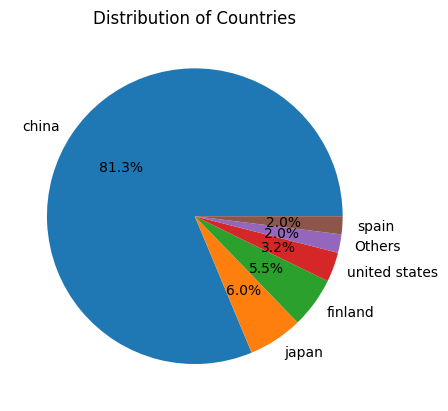

In [151]:
# Get the top 5 countries
top_5_countries = df_merged_fin['country'].value_counts().head(5).index.tolist()

# Replace countries not in the top 5 with 'Other'
df_merged_fin['top_countries'] = df_merged_fin['country'].apply(lambda x: x if x in top_5_countries else 'Other')

# Pie Chart showing distribution of the top 5 countries
country_count = df_merged_fin['top_countries'].value_counts() 
labels = ['china', 'japan', 'finland', 'united states', 'Others', 'spain']

plt.pie(country_count, labels = labels, autopct='%1.1f%%')
plt.title("Distribution of Countries")
plt.show()

**Takeaways**:
- China dominates the dataset, comprising a significant majority at 81.3%, indicating that the dataset is heavily skewed toward Chinese records.
- Japan and Finland follow, but with much smaller percentages (6% and 5.5%, respectively), suggesting that while they are significant, their representation is much less than China.
- The United States and Spain are the smallest among the top countries represented, each accounting for just over 3% and 2% of the records, respectively.
- The "Others" category, which aggregates all countries not in the top five, makes up a small percentage (2%), suggesting that no other single country significantly impacts the overall distribution.
- From a business or research perspective, the heavy skew towards China might suggest focusing on Chinese market trends, consumer behavior, or regulatory impacts, as they would be most representative of the dataset. However, this also indicates a potential lack of diversity in the data, which might limit the applicability of findings to other regions.
- The pie chart is effective for showing the dominance of China but may not be the best tool for comparing the smaller segments due to the large disparity.

**Feature Engineering: One Hot Encoding:**

As seen in the pie chart, the top 5 countries account for around 98% of the observations and 2% as the other. 

We believe this is sufficient to encode the top five countries by name and label the rest as the Others. 

Based on that idea of top five countries, we will be creating a new column called top_countries_encoded that encode the top five countries and the rest. 

In [152]:
df_merged_fin['top_countries'].value_counts().reset_index()

,top_countries,count
0,china,1553756
1,japan,113827
2,finland,105799
3,united states,62018
4,Other,38579
5,spain,37590


In [153]:
# One hot encoding for top_countries/countries

# Create a copy of df_merged_fin to perform 
one_hot = df_merged_fin.copy()

one_hot['top_countries'] = one_hot['top_countries'].astype('category') # Converting to category type
one_hot = pd.get_dummies(one_hot[['top_countries']], drop_first = True) # Getting dummies
one_hot = one_hot.astype(int) # Turning True and False to 1 and 0s
df_merged_fin = pd.concat([df_merged_fin, one_hot], axis = 1) # Concatenating the encoded variables with the main dataframe

### EDA 6: Analysis of year founded:

**Purpose:**
* To display the distribution of the year in which the companies were founded at the company level 


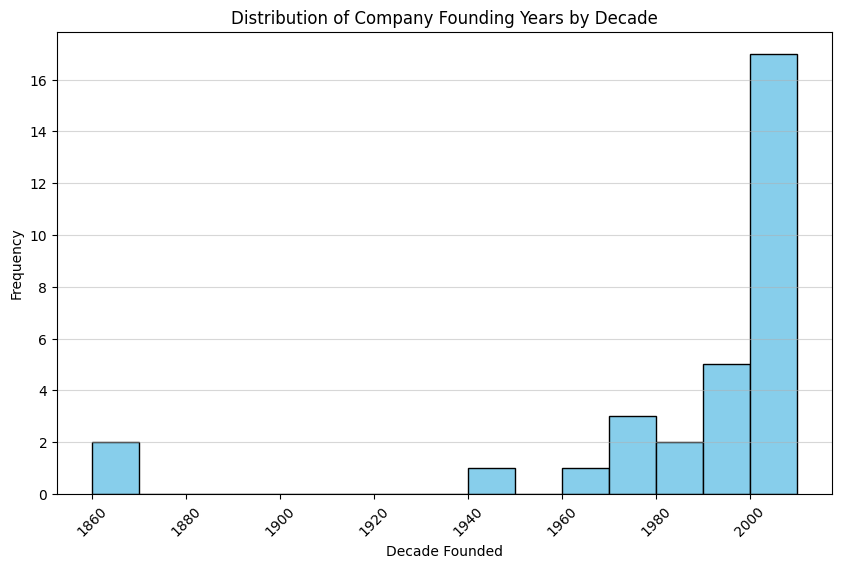

In [154]:
# Group the data by company and calculate the founding year for each company
company_founding_years = df_merged_fin.groupby('brand')['year founded'].min()

# Filter out invalid (zero) and missing values in the founding year
valid_years = company_founding_years[company_founding_years != 0]

# Round the founding year to decades
decade_founded = (valid_years // 10) * 10

# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.hist(decade_founded, bins=range(int(decade_founded.min()), int(decade_founded.max()) + 10, 10), color='skyblue', edgecolor='black')
plt.title('Distribution of Company Founding Years by Decade')
plt.xlabel('Decade Founded')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)  # Add grid lines for better readability
plt.show()

**Takeaway:**

* It reveals a pronounced trend: a surge in the inception of electronics companies during the late 20th and early 21st centuries. This pattern reflects the dynamic landscape of the electronics sector, contrary to sectors such as oil that are less dynamic in nature. 

* Understanding the age of a company is a critical element of our analysis. The length of time a company has been operational can significantly influence consumer perceptions of reliability and trustworthiness. Brands with a long-standing heritage are often perceived as more dependable, which can affect consumer loyalty and confidence. Conversely, newer companies may be associated with innovation but might need to work harder to establish consumer trust. Therefore, incorporating the foundation era of these companies into our study allows us to draw more nuanced conclusions about brand reputation and its potential impact on consumer behavior in the electronics market.

### EDA 7: Trying to understand if there is a class imbalance:

**Purpose**

* We wanted to see the distribution of our target variable. In particular, we wanted to examine whether there would be a class-imbalance. 


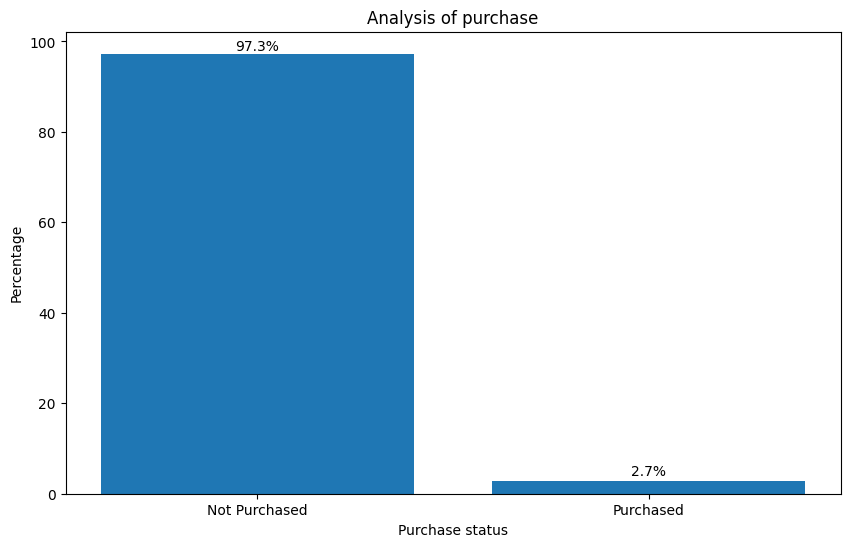

In [155]:
purchased_values = df_merged_fin['purchased'].value_counts().reset_index()

# Calculate the total count of each purchase status
total_count = purchased_values['count'].sum()

# Calculate the percentage for each purchase status
purchased_values['percentage'] = (purchased_values['count'] / total_count) * 100

plt.figure(figsize=(10,6))

# Plot the bar graph
plt.bar(purchased_values['purchased'], purchased_values['percentage'])

# Add percentage labels on top of each bar
plt.text(0, purchased_values['purchased'][0] + 98, f"{round(purchased_values['percentage'][0], 2)}%", ha='center')
plt.text(1, purchased_values['purchased'][1] + 3, f"{round(purchased_values['percentage'][1], 2)}%", ha='center')

# Add labels and title
plt.xlabel("Purchase status")
plt.ylabel("Percentage")
plt.title("Analysis of purchase")
plt.xticks([0, 1], ['Not Purchased', 'Purchased'])  # Adding custom labels for x-axis

# Show the plot
plt.show()

**Takeaway**

* As expected, we observe a class-imbalance in our dependent variable. Specifically, 97.3% of customers interacting with a given product did not purchase them while only 2.7% actually bought the product that they looked online. This would affect our analysis because this may mean that we would need to implement strategies such as oversampling or undersampling to address the class-imbalance in our machine learning models. 

### EDA 8: Distribution of prices for purchased vs not purchased

**Purpose of this graph**:
- This plot is created to visually compare how the prices of products differ between those that were purchased and those that were not.
- The intent is to investigate whether price influences purchasing decisions, which could be indicative of price sensitivity among consumers.

/var/folders/p6/wmyhr91j07x0g9h2lglh__jh0000gn/T/ipykernel_23885/1878430376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='purchased', y='price', data=df_merged_fin, palette='coolwarm')


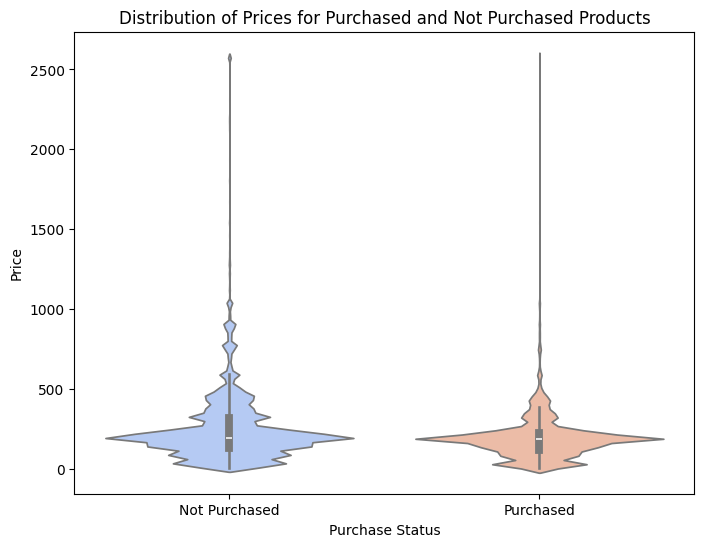

In [156]:
# Box plot to compare the distribution of prices for purchased and not purchased products
plt.figure(figsize=(8, 6))
sns.violinplot(x='purchased', y='price', data=df_merged_fin, palette='coolwarm')
plt.title('Distribution of Prices for Purchased and Not Purchased Products')
plt.xlabel('Purchase Status')
plt.xticks([0, 1], ['Not Purchased', 'Purchased'])  # Adding custom labels for x-axis
plt.ylabel('Price')
plt.show()

The graph is a violin plot, which combines the features of a box plot with a kernel density plot, providing a deeper understanding of the distribution of numerical data. It's used to compare the distribution of prices between products that were purchased and those that were not.

- Each 'violin' represents the distribution of prices for one of the two categories: 'Purchased' and 'Not Purchased'.
- The thickness of the violin at different price levels indicates the frequency of data points; wider sections represent a higher density of data points at a given price.
- Inside each violin, there is a box plot that includes a white dot for the median price, a thick bar for the interquartile range (IQR), and 'whiskers' that extend to show the range of the distribution, excluding outliers.

**Takeaways**:
- Both distributions have long tails extending to higher prices, indicating that while there are items with high prices in both categories, they are less frequent.
- The 'Purchased' category has a distribution that appears to be more concentrated around the median price, suggesting that purchased products tend to cluster around a certain price range.
- Conversely, the 'Not Purchased' category appears to be more spread out, with a less pronounced peak, indicating more variability in the prices of items that are not purchased.
- There may be outliers in both categories, as suggested by the long tails, indicating that there are some very high-priced products that both are and are not purchased.
- The median price of the 'Purchased' category is lower than that of the 'Not Purchased' category. This could suggest that customers are more likely to purchase products that are priced lower, pointing towards price sensitivity.

### EDA 9: Distribution of total views and total additions to cart for those purchasing vs. those not purchasing

In this section, we will be analysing the distribution of total views and total carts for the products where purchases were made vs products where purchases were not made. This will help us understand why/how important it is to consider 'total_views' and 'total_carts' as a feature in our ML model

For those purchasing:

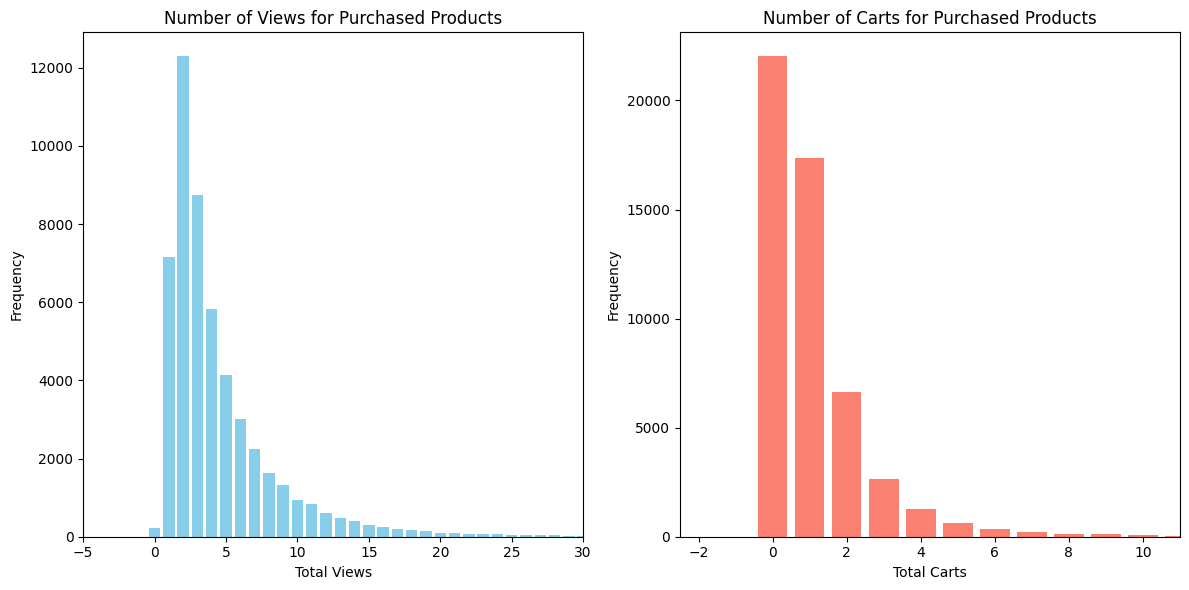

In [157]:
# EDA on number of visits for those purchasing 
purchased = df_merged_fin[df_merged_fin['purchased']==1]
purchased_view_count = purchased['total_views'].value_counts().reset_index()
purchased_cart_count = purchased['total_carts'].value_counts().reset_index()

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot for total_views
axs[0].bar(purchased_view_count['total_views'], purchased_view_count['count'], color='skyblue')
axs[0].set_title('Number of Views for Purchased Products')
axs[0].set_xlabel('Total Views')
axs[0].set_ylabel('Frequency')
axs[0].set_xlim(-5, 30)

# Plot for total_carts
axs[1].bar(purchased_cart_count['total_carts'], purchased_cart_count['count'], color='salmon')
axs[1].set_title('Number of Carts for Purchased Products')
axs[1].set_xlabel('Total Carts')
axs[1].set_ylabel('Frequency')
axs[1].set_xlim(-2.5, 11)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

The set of graphs shows two histograms: one for the number of views and another for the number of carts associated with purchased products in the dataset `df_merged_fin`.

- The left histogram depicts the frequency of purchased products against the total number of views they received before purchase. 
- The right histogram illustrates the frequency of purchased products against the total number of times they were added to a cart before purchase. 

**Why we plotted it**:
- We plotted these histograms to analyze user engagement with products that led to a purchase.
- By understanding the typical number of views and cart additions before a purchase, we can infer patterns in customer behavior and the purchasing process.
- These insights help in optimizing the sales funnel by focusing on user engagement strategies that encourage conversions.

**Takeaways**:
- From the 'Number of Views for Purchased Products' histogram, it's evident that most purchases occur with relatively few views, indicating that customers often decide to purchase quickly after viewing the product a limited number of times.
- The distribution of views is skewed to the right, with the frequency decreasing as the number of views increases, suggesting that fewer customers take a large number of views before deciding to purchase.
- The 'Number of Carts for Purchased Products' histogram shows a similar pattern, where most purchased products are added to the cart once or twice, with diminishing frequency as the number of cart additions increases.
- A decrease in frequency with increasing carts could indicate that customers who add a product to their cart multiple times are less likely to purchase it.

The analyses from these histograms can inform marketing strategies to minimize the time and interaction needed before a purchase decision is made. They also highlight the importance of a seamless and persuasive first view of the product, as well as the significance of simplifying the cart process to encourage quick conversions from cart to purchase.

For those not purchasing:

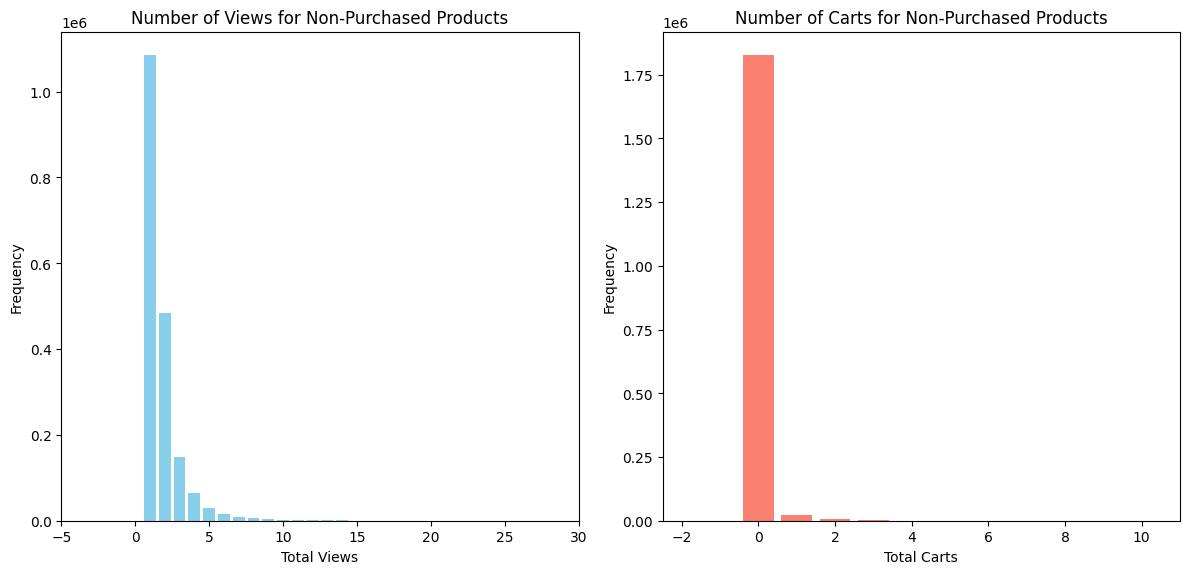

In [158]:
# EDA on number of visits for those NOT purchasing 
not_purchased = df_merged_fin[df_merged_fin['purchased']==0]
not_purchased_view_count = not_purchased['total_views'].value_counts().reset_index()
not_purchased_cart_count = not_purchased['total_carts'].value_counts().reset_index()

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot for total_views
axs[0].bar(not_purchased_view_count['total_views'], not_purchased_view_count['count'], color='skyblue')
axs[0].set_title('Number of Views for Non-Purchased Products')
axs[0].set_xlabel('Total Views')
axs[0].set_ylabel('Frequency')
axs[0].set_xlim(-5, 30)

# Plot for total_carts
axs[1].bar(not_purchased_cart_count['total_carts'], not_purchased_cart_count['count'], color='salmon')
axs[1].set_title('Number of Carts for Non-Purchased Products')
axs[1].set_xlabel('Total Carts')
axs[1].set_ylabel('Frequency')
axs[1].set_xlim(-2.5, 11)

# Adjust layout
plt.tight_layout()

# Show the plots
plt.show()

The set of graphs displays two histograms comparing user engagement metrics—specifically, the number of views and carts—for products that were not purchased.

**Purpose of this graph**:
- The histograms were plotted to analyze the engagement level of users with products they did not end up purchasing.
- This analysis helps identify patterns in user behavior that might indicate barriers to purchase or lack of conversion despite interest (as shown by views and carts).

**Takeaways**:
- The 'Number of Views for Non-Purchased Products' histogram indicates that a high number of products are viewed only once or twice before being abandoned, which suggests that initial interest does not necessarily lead to a purchase.
- The rapid decrease in frequency as the number of views increases shows that fewer users tend to repeatedly view products they don't buy, hinting at a quick drop-off in interest.
- The 'Number of Carts for Non-Purchased Products' histogram shows a very high frequency for products added to the cart once and not purchased, which highlights a significant barrier or point of friction in the conversion process post-initial interest.
- The quick drop-off in frequency with an increasing number of cart additions suggests that if a product is added to the cart and not purchased on the first attempt, it is increasingly less likely to be purchased with subsequent additions.

### EDA 10: Cart to purchase conversion rate:

The below graph is a pie chart that compares the cart abandonment rate to the conversion rate, which are key metrics in e-commerce analysis.

**Why we plotted it**:
- The chart is plotted to quickly understand the effectiveness of the purchasing process and to identify opportunities for improvement.
- It visually communicates the relationship between carts created and purchases completed, which can inform decision-making regarding checkout process optimizations.
- The pie chart format is chosen for its simplicity and because the metrics are complementary, summing up to 100%.

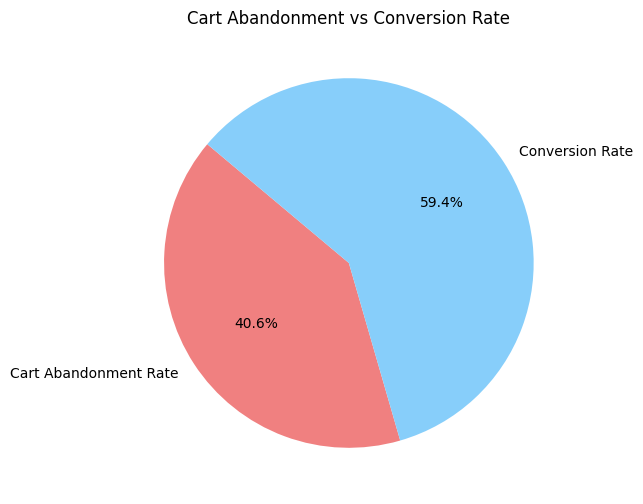

In [159]:
# Calculate the number of completed purchases
num_completed_purchases = df_merged_fin[df_merged_fin['purchased'] == 1]['total_purchases'].sum()

# Calculate the number of carts created
num_carts_created = df_merged_fin['total_carts'].sum()

# Calculate the cart abandonment rate
cart_abandonment_rate = ((num_carts_created - num_completed_purchases) / num_carts_created) * 100

# Calculate the conversion rate
conversion_rate = (num_completed_purchases / num_carts_created) * 100

# Pie chart data
labels = ['Cart Abandonment Rate', 'Conversion Rate']
sizes = [cart_abandonment_rate, conversion_rate]
colors = ['lightcoral', 'lightskyblue']

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Cart Abandonment vs Conversion Rate')
plt.show()


**Takeaways**:
- A cart abandonment rate of 40.6% suggests that a significant portion of potential sales is not being realized, as many customers who add items to their carts do not complete the purchase.
- A conversion rate of 59.4% is relatively high, which suggests that more than half of the customers who add items to their carts go on to complete the purchase. This could be indicative of effective conversion tactics or a streamlined checkout process.
- The balance between abandonment and conversion rates could be due to various factors, such as user experience during checkout, pricing, shipping costs, return policies, website performance, or payment options offered.
- Efforts to reduce cart abandonment and improve the conversion rate might include simplifying the checkout process, offering competitive pricing, introducing free shipping, or retargeting customers with reminders and offers.

These insights can help businesses prioritize which aspects of the customer experience to improve upon to reduce cart abandonment and increase the conversion rate.

#### Exploratory Data Analysis (EDA) Highlights

Our exploratory data analysis (EDA) reveals distinct price distribution patterns across various product subcategories and industries. Notably, we discovered a significant trend: customers who add a product to their cart have approximately a 59% likelihood of completing the purchase. Beyond this cart-to-purchase conversion, we explored the general purchase rates and identified a substantial imbalance—97.3% of customers who view products online do not proceed to purchase. These findings highlighted the need to include variables related to subcategories, industries, price, the number of visits, and the number of carts to have effective machine learning models. We also saw that the country that a product is from, the industry and the cateogry are diverse and therefore can have an impact on the purchasing of the product.

Now that we are done exploring the data, we will move to the machine learning portion of the report. 

# Machine Learning:

We are now done with setting up the dataframe for analysis and understanding the columns and the relationships between them, their distributions, etc. -- and below represent a sample of our dataset

In [160]:
df_merged_fin.head(5) 

,user_id,product_id,price,total_views,total_carts,total_purchases,year founded,industry,size range,country,...,top_companies_nokia,top_companies_oppo,top_companies_sony,top_companies_xiaomi,top_countries,top_countries_china,top_countries_finland,top_countries_japan,top_countries_spain,top_countries_united states
0,224520397,8800028,43.50,1,0,0,0.0,information technology and services,1 - 10,united states,...,0,0,0,0,united states,0,0,0,0,1
1,239475080,11300053,17.45,1,0,0,0.0,information technology and services,1 - 10,united states,...,0,0,0,0,united states,0,0,0,0,1
2,239876607,1004777,135.01,2,0,0,2010.0,internet,51 - 200,china,...,0,0,0,1,china,1,0,0,0,0
4,239876607,1004886,153.88,1,0,0,0.0,telecommunications,5001 - 10000,china,...,0,1,0,0,china,1,0,0,0,0
5,239876607,1004956,375.79,4,0,0,2010.0,internet,51 - 200,china,...,0,0,0,1,china,1,0,0,0,0


Below are the features we are going to include for our ML model - this includes every column in df_merged_fin except `user_id`, `product_id`, `total_purchases` and `purchased`.

In [161]:
features_with_companies = ['price',
 'total_views',
 'total_carts',
 'year founded',
 'is_yearfounded_null',
 'category_code_electronics.audio.headphone',
 'category_code_electronics.audio.microphone',
 'category_code_electronics.audio.music_tools.piano',
 'category_code_electronics.audio.subwoofer',
 'category_code_electronics.camera.photo',
 'category_code_electronics.camera.video',
 'category_code_electronics.clocks',
 'category_code_electronics.smartphone',
 'category_code_electronics.tablet',
 'category_code_electronics.telephone',
 'category_code_electronics.video.projector',
 'category_code_electronics.video.tv',
 'industry_entertainment',
 'industry_health, wellness and fitness',
 'industry_information technology and services',
 'industry_internet',
 'industry_music',
 'industry_telecommunications',
 'size_range_encoded',
 'top_companies_bq',
 'top_companies_nokia',
 'top_companies_oppo',
 'top_companies_sony',
 'top_companies_xiaomi',
 'top_countries_china',
 'top_countries_finland',
 'top_countries_japan',
 'top_countries_spain',
 'top_countries_united states']

Let us plot a correlation heat map to understand if there is any redudancy that can be eliminated:

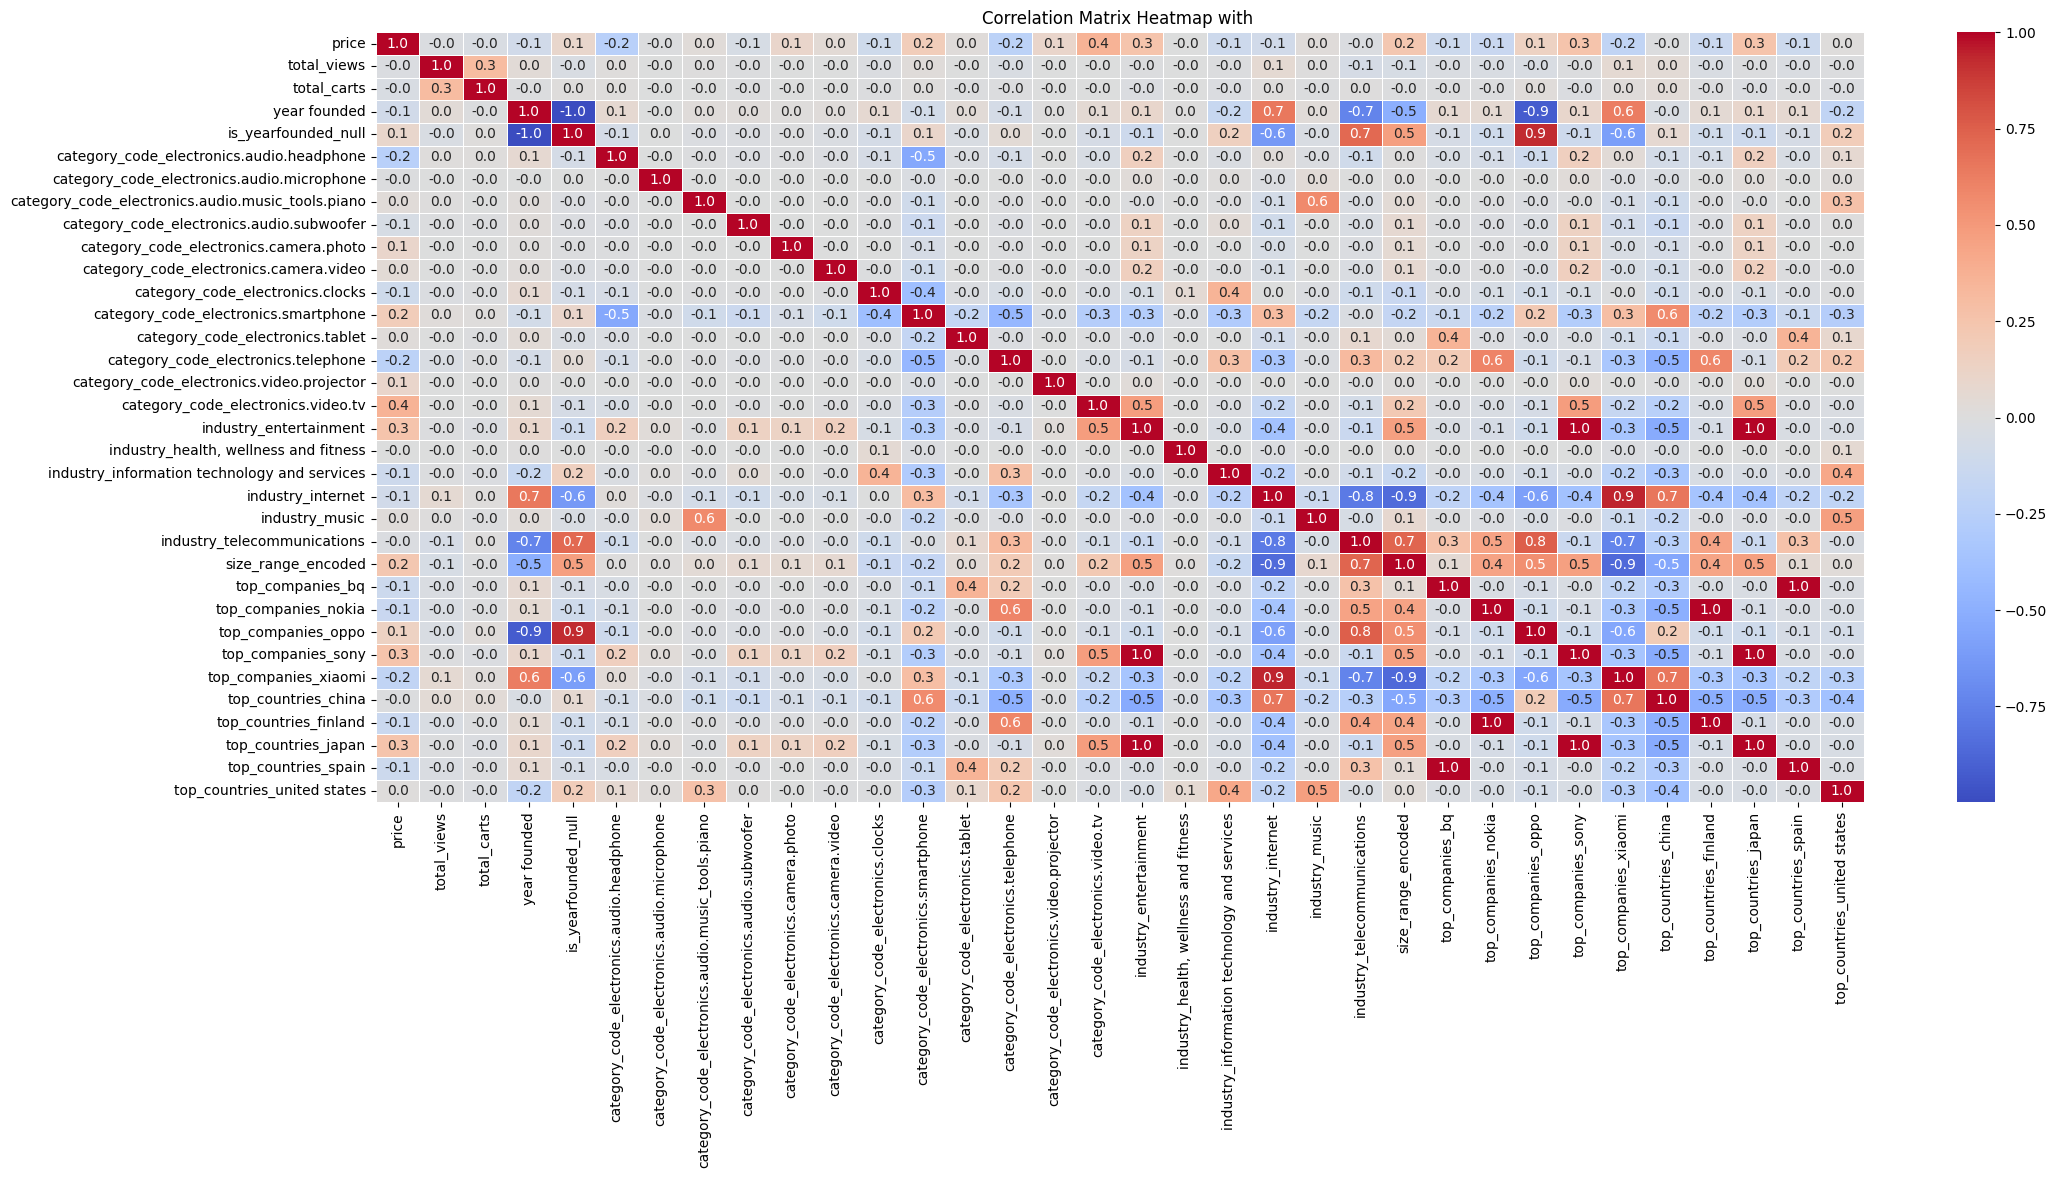

In [162]:
X = df_merged_fin[features_with_companies]
correlation_matrix = X.corr()

# Plotting the correlation matrix heatmap
plt.figure(figsize=(24, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap with ")
plt.show()


The heatmap visualizes the correlation matrix of various features in the `df_merged_fin` dataset, which encompasses product categories, industry specifics, company size, and geographical data, among others.

**What the graph is**:
- This heatmap offers a detailed view of how features in the dataset correlate with one another, displaying correlation coefficients that range from -1 to 1. Values close to 1 indicate a strong positive correlation, suggesting that as one feature increases, the other does as well. Conversely, values close to -1 indicate a strong negative correlation, where one feature's increase corresponds to the other's decrease. Values around 0 imply a lack of linear correlation.

**Why we plotted it**:
- The primary purpose of the heatmap is to detect patterns of correlation between different variables that could influence analytical outcomes, particularly in predictive modeling. Identifying these patterns helps in assessing whether certain variables might carry redundant information.
- Spotting high correlations is essential for avoiding multicollinearity in predictive modeling, which can skew or invalidate the results of regression analyses and other algorithms that assume feature independence.
- The heatmap also aids in feature selection by highlighting which variables contribute unique information and which do not, helping streamline the model for efficiency and better performance.

**Key Takeaways**:
- The graph reveals several instances of strong correlations between different features, suggesting potential redundancies. For instance, features with a correlation coefficient of 1.0 might be duplicative and we will remove one of them to simplify the model and reduce redundancy.
- Despite strong correlations observed between `year_founded` and `is_yearfounded_null`, both are retained because `year_founded` provides historical context which is valuable for understanding company longevity and its potential influence on consumer trust and purchasing decisions. `is_yearfounded_null` indicates data completeness, marking where founding year information was originally missing.


We are going to only consider dropping variables that give us a correlation of 1 or -1, since we dont' want to potentially lose any important information by dropping other (encoded) variables

**Since the encoded brands seem to be the variables that tend to create the most correlated variables (i.e., 1 here), we will be dropping them.**

Thus, the updated correlation matrix heatmap below reflects a revised set of features from the `df_merged_fin` dataset, emphasizing a strategic reduction in the number of features by removing those that exhibited high correlations with others in the previous analysis.

In [163]:
features_without_companies = ['price',
 'total_views',
 'total_carts',
 'year founded',
 'is_yearfounded_null',
 'category_code_electronics.audio.headphone',
 'category_code_electronics.audio.microphone',
 'category_code_electronics.audio.music_tools.piano',
 'category_code_electronics.audio.subwoofer',
 'category_code_electronics.camera.photo',
 'category_code_electronics.camera.video',
 'category_code_electronics.clocks',
 'category_code_electronics.smartphone',
 'category_code_electronics.tablet',
 'category_code_electronics.telephone',
 'category_code_electronics.video.projector',
 'category_code_electronics.video.tv',
 'industry_entertainment',
 'industry_health, wellness and fitness',
 'industry_information technology and services',
 'industry_internet',
 'industry_music',
 'industry_telecommunications',
 'size_range_encoded',
 'top_countries_china',
 'top_countries_finland',
 'top_countries_japan',
 'top_countries_spain',
 'top_countries_united states']

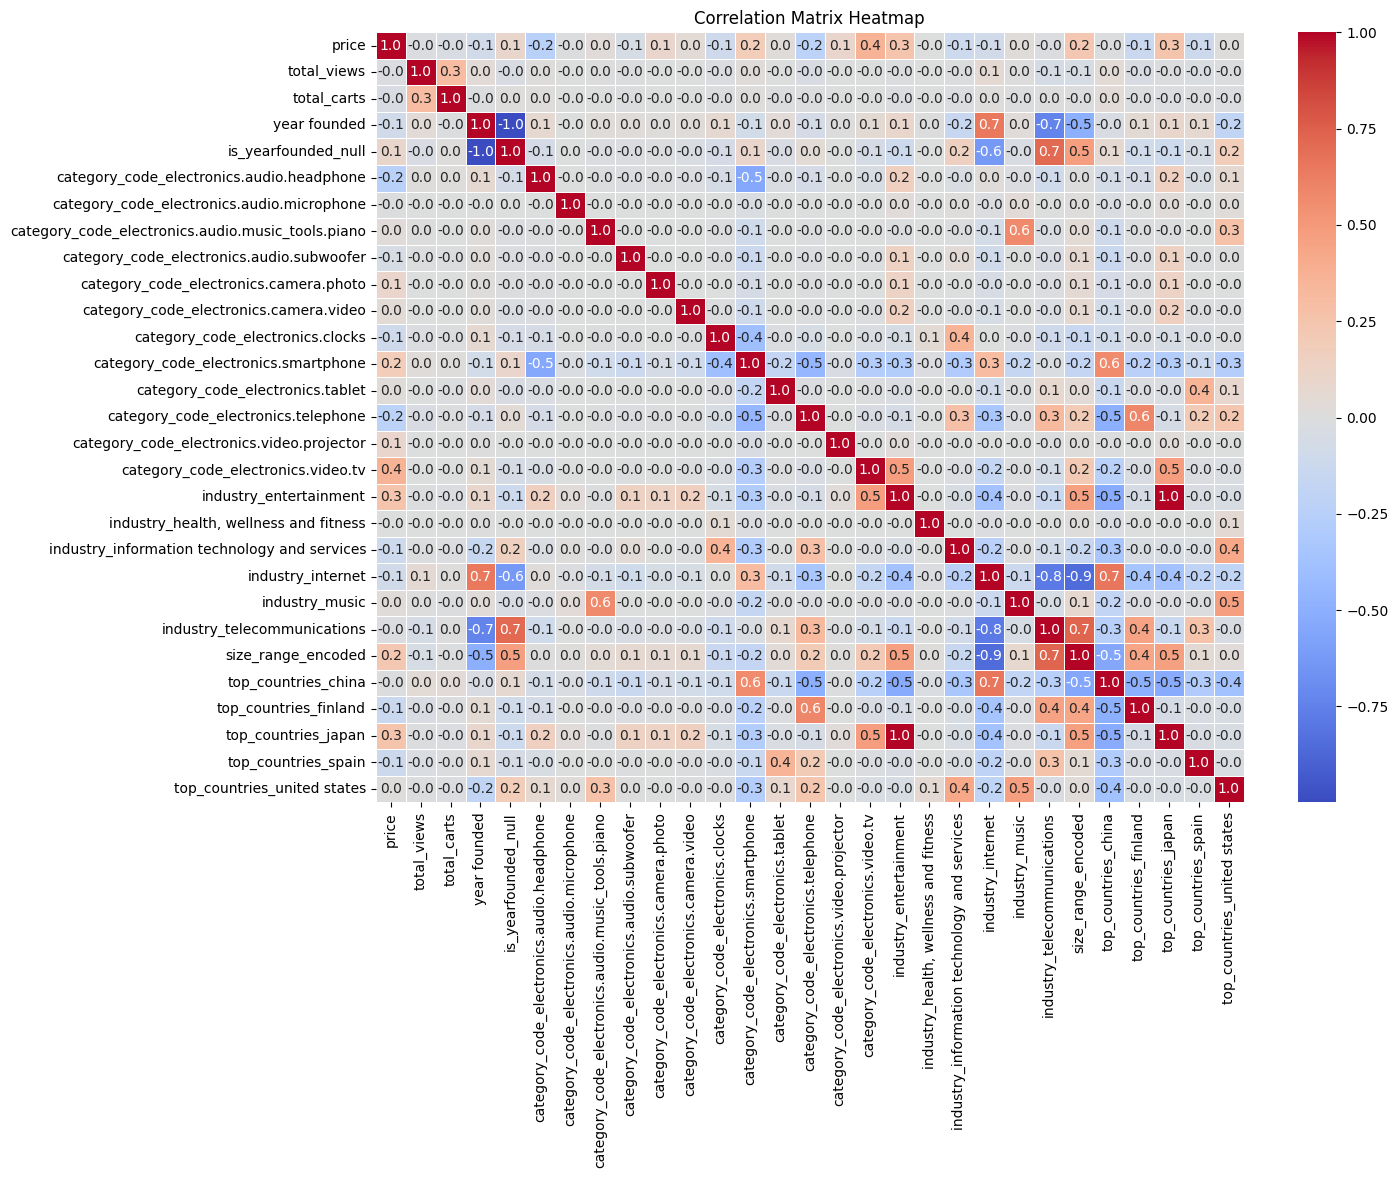

In [164]:
X = df_merged_fin[features_without_companies]

# Since X is our feature matrix - we are running correlation on that 
correlation_matrix = X.corr()

# Plotting the correlation matrix heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".1f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

**Key Differences from the Previous Correlation Graph**:

**Removal of Highly Correlated Features**: The primary difference in this heatmap compared to the previous one is the exclusion of features that showed high correlation with others, ie. the brands encoded. High correlations can lead to multicollinearity in predictive modeling, which can skew the results and make the model unstable. The removed features likely duplicated the informational content provided by other features in the dataset. By excluding features with high correlations, the heatmap now presents a set of variables that are more statistically independent from each other. This reduces redundancy in the data, helping to simplify the model and potentially improving its performance by focusing only on features that provide unique information.

The revised heatmap is not just an updated visualization but a strategic refinement of the dataset. We can see here that there are is only one combination of variables that has a correlation of -1, which is `top_countries_japan` and `industry_entertainment`. So let's drop one of them - we chose to drop `industry_entertainment`

Below are our finalized features after feature selection (through elimination) using the correlation heat map:

In [165]:
features = ['price',
 'total_views',
 'total_carts',
 'year founded',
 'is_yearfounded_null',
 'category_code_electronics.audio.headphone',
 'category_code_electronics.audio.microphone',
 'category_code_electronics.audio.music_tools.piano',
 'category_code_electronics.audio.subwoofer',
 'category_code_electronics.camera.photo',
 'category_code_electronics.camera.video',
 'category_code_electronics.clocks',
 'category_code_electronics.smartphone',
 'category_code_electronics.tablet',
 'category_code_electronics.telephone',
 'category_code_electronics.video.projector',
 'category_code_electronics.video.tv',
 'industry_health, wellness and fitness',
 'industry_information technology and services',
 'industry_internet',
 'industry_music',
 'industry_telecommunications',
 'size_range_encoded',
 'top_countries_china',
 'top_countries_finland',
 'top_countries_japan',
 'top_countries_spain',
 'top_countries_united states']

We now define our X and y for ML and are ready to begin with modelling:

In [167]:
X = df_merged_fin[features]
y = df_merged_fin['purchased']

### Justification for Non-Scaling
Model Insensitivity to Feature Scale: Tree-based models, which are used in our project (Random Forest and Gradient Boosting), do not require feature scaling to perform effectively. These models are insensitive to the magnitude of features as they involve splitting nodes in trees based on order statistics (e.g., median) rather than by assuming any specific distribution of feature values.

Impact on Interpretability: Not scaling the data can sometimes aid in keeping the interpretability of the model outputs more straightforward. For example, seeing a split in a tree using the actual values of 'Year Founded' or 'Price' can be more interpretable than scaled values, where the relation to real-world quantities isn't immediately clear.

Ordinal Nature of Some Features: For the ordinal encoded features, scaling is not straightforward as it can disrupt the order encoded within the numbers. Scaling such features could potentially lead to a loss of valuable ordinal information which is crucial for making the correct splits in the context of tree-based models.

# Training and Testing

We are creating a ML model to be able to predict whether a purchase will be made or not depending on all the features we have explored, selected and engineered in the previous section. 

### Approach/Methods


#### End-to-End Pipeline
The project pipeline is structured as follows:

1. **Data Splitting**:
   - **Training and Testing**: The data is initially split into an 80% training set and a 20% testing set. This division ensures that the model can be trained on a substantial portion of the data while still being validated and tested on unseen data.
   - **Validation Split**: Further, the training data is split again into 75% training and 25% validation sets. The validation set is crucial for tuning the models and preventing overfitting.

2. **Resampling**:
   - To address potential class imbalances (common in purchase prediction datasets where purchases are typically fewer than non-purchases), we applied Random Over Sampling (ROS) on the training data. This method helps in balancing the classes by increasing the number of samples in the minority class by duplicating them. It is crucial to perform this step only on the training data to prevent information leakage and overly optimistic model evaluation.

3. **Model Training and Hyperparameter Tuning**:
   - Each model is trained using the resampled training data, with hyperparameters optimized through grid search. Grid search is conducted with cross-validation on the training and validation datasets, ensuring the selection of the best parameters based on the model's performance. This rigorous approach helps in identifying the most effective model settings to enhance predictive accuracy.
   - **Grid Search**: It involves exhaustive searching through a manually specified subset of the hyperparameter space of the chosen model, guided by performance metrics on the validation data.

4. **Evaluation**:
   - Finally, the best-performing models (as determined by grid search) are evaluated using the independent test set. This evaluation phase helps to gauge the real-world efficacy of the models, assessing how well they generalize to new, unseen data.

#### Key Considerations
- **Handling Overfitting**: By using a separate validation set and employing techniques like resampling and cross-validation, we mitigate the risk of overfitting, ensuring our models remain generalized and effective for unseen data.
- **Model Assessment**: The final model's performance is evaluated on the test set using metrics suitable for classification tasks, such as accuracy, and recall. These metrics provide a comprehensive view of model efficacy, particularly in how well the model handles imbalanced data.

Through this structured approach, our project aims to deliver robust predictive models that can effectively identify key drivers of purchase behavior, thereby aiding businesses in strategizing more effective marketing and sales initiatives.

**Basic ML models**

First, we will partition our dataset into three subsets: a test set comprising 20% of the data, which will remain untouched until the final evaluation stage; a validation set constituting 25% of the remaining data, which will be used for hyperparameter tuning and performance assessment during model development; and a training set encompassing the remaining 75% of the remaining data (60% of the total data available), which will be utilized to train the models. The validation set will serve as a gauge for testing metrics such as accuracy, precision, and recall, allowing us to fine-tune the models' hyperparameters. Once the optimal parameters are determined, the best-performing models will be applied to the test set for final evaluation, ensuring unbiased performance assessment on unseen data. The reason we are doing this rather than cross validation is because our dataset is large enough and allows us to have a separate test set.

Adding `stratify=y` when splitting the dataset into training and testing sets ensures that the class distribution is preserved in both subsets. In other words, it ensures that the proportion of classes (or target variable categories) remains consistent between the training and testing data.

Without stratification, there's a risk that one of the subsets may end up with a significantly different class distribution than the others, which can lead to biased model performance evaluation. By using `stratify=y`, you help ensure that your model is trained and evaluated on representative samples of both classes, leading to more reliable and accurate performance metrics.

In [168]:
# First, split the data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Then, split the training data further into training and validation sets (75% train, 25% validation)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42, stratify=y_train)

Rather than writing code for model implementation every time we run the model, we wanted to standaridize the process in which we implement the models by writing a function to display the model metrics along with its confusion matrix

While we will be including accuracy and recall to be comprehensive, the metric we are most interested in is the recall. 

Using recall as the main metric for eCommerce purchase prediction (binary classification) can be justified because we are interested in maximizing  purchase. In eCommerce, the primary goal is often to maximize revenue by increasing the number of successful purchases. Recall directly measures the ability of the model to capture true positive instances (actual purchases) out of all actual positive instances. Maximizing recall ensures that the model identifies as many potential purchase opportunities as possible, thereby increasing the chances of converting users into customers and maximizing revenue.

Capturing Maximum Potential Purchases:

Business Impact: In eCommerce settings, each potential purchase represents a revenue opportunity. By maximizing recall, the model identifies as many actual purchasers as possible, reducing the risk of missing out on these opportunities.

Growth Strategy: High recall ensures that marketing efforts, such as promotions and personalized recommendations, reach most, if not all, potential buyers. This can be crucial for driving sales volumes and improving top-line performance.

Resource Allocation: While targeting false positives (customers predicted to purchase but who do not) does involve some misallocation of marketing resources, these costs are often lower in comparison to the lost revenue from missed sales. Moreover, interactions with these customers might still provide value in terms of brand engagement or future conversion.


In [169]:
def classification_model(model, X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, text="Validation"):
    # Fit the model
    model.fit(X_train, y_train)

    # Predict probabilities for the positive class
    y_probs_train = model.predict_proba(X_train)[:, 1]  # Probabilities for the positive class
    y_probs_val = model.predict_proba(X_val)[:, 1]

    # Predict on validation set
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)

    # Calculate accuracy, precision, recall, F1-score, and AUC for the training set
    accuracy_train = accuracy_score(y_train, y_pred_train)
    recall_train = recall_score(y_train, y_pred_train)
    auc_train = roc_auc_score(y_train, y_probs_train)

    # Calculate standard classification metrics
    accuracy_val = accuracy_score(y_val, y_pred_val)
    recall_val = recall_score(y_val, y_pred_val)
    auc_val = roc_auc_score(y_val, y_probs_val)

    # Generate ROC curve data
    fpr, tpr, _ = roc_curve(y_val, y_probs_val)
    roc_auc = auc(fpr, tpr)  # Compute Area Under the Curve

    print("\nTraining Metrics:")
    print("Accuracy:", accuracy_train)
    print("Recall:", recall_train)
    print("AUC ROC:", auc_train)

    # Print the metrics
    print("\n" + text + " Metrics:")
    print("Accuracy:", accuracy_val)
    print("Recall:", recall_val)
    print("AUC ROC:", auc_val)

    # Confusion matrix for training data
    conf_matrix_train = confusion_matrix(y_train, y_pred_train)
    print("\nConfusion Matrix (Training):")
    print(conf_matrix_train)

    # Confusion matrix
    conf_matrix_val = confusion_matrix(y_val, y_pred_val)
    print("\nConfusion Matrix (" + text + "):")
    print(conf_matrix_val)

    # Plotting ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title("Receiver Operating Characteristic for " + text + " set")
    plt.legend(loc="lower right")
    plt.show()

#### Model 1: Logistic Regression

Logistic regression has the following pros and cons: 

 - Logistic regression is a simple yet effective linear model widely used for binary classification tasks.
   - This model is highly interpretable, as it provides clear coefficients indicating the direction and magnitude of the impact of each feature on the prediction. This is crucial when the goal is to understand feature importance.
   - Logistic regression is computationally efficient and scales well to large datasets.
   - Logistic Regression assumes a linear relationship between the logit of the outcome and each predictor. This assumption can be overly simplistic when dealing with complex patterns or interactions between features, potentially leading to biased predictions if nonlinear relationships exist.
   - This model also assumes that the predictors are independent of each other. In real-world scenarios, features can be correlated, and ignoring these correlations can lead to biased coefficient estimates and hence, misleading conclusions about feature importance.
   - It serves as an excellent baseline model for binary classification problems, allowing for straightforward assessment of more complex models.


/Users/vaidehisom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Training Metrics:
Accuracy: 0.9742602278582769
Recall: 0.17991038328873987
AUC ROC: 0.891773629523627

Validation Metrics:
Accuracy: 0.9741809088864127
Recall: 0.17387099893627309
AUC ROC: 0.8900076818330472

Confusion Matrix (Training):
[[1111838    4082]
 [  25440    5581]]

Confusion Matrix (Validation):
[[370645   1328]
 [  8543   1798]]


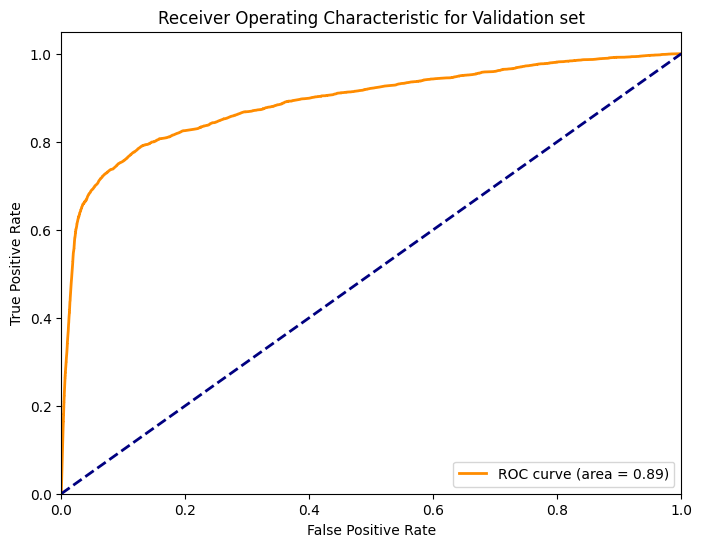

In [170]:
lgr = LogisticRegression()
classification_model(lgr)

Now we are going to try another model - Random Forest Classifier to try and improve on this baseline model.

#### Model 2: Random Forest:

Our reasoning for employing random forest model is as follows: 

  - Random forest is an ensemble learning method that combines multiple decision trees to improve predictive performance.
   - It is robust to overfitting and tends to generalize well to unseen data.
   - Unlike logistic regression, random forest is capable of handling non-linear relationships between features, thus providing robustness and better performance on complex datasets.
   - Random Forest offers a built-in method to rank features based on their importance, derived from how often a feature is used to split decisions in trees, making it invaluable for feature analysis.
   - Random forest is less sensitive to outliers and missing data compared to some other models, which can be advantageous for ecommerce datasets that may contain noise or incomplete information.
  
The biases in random forest are:
   - **Bias in Tree Structure**: Random Forest, being an ensemble of decision trees, can inherit biases associated with decision trees. For example, trees often have a bias toward attributes with more levels (e.g., categorical variables with many categories), potentially splitting them preferentially and giving these attributes undue importance.
   - **Sampling Bias**: Since Random Forest relies on bootstrap aggregating (bagging), where each tree is trained on a random sample of the data, there's potential for sampling bias. If some observations are more likely to be included in these samples, the model's predictions can be biased toward these observations.



Training Metrics:
Accuracy: 0.9825370267520299
Recall: 0.4736146481415815
AUC ROC: 0.9555538109800991

Validation Metrics:
Accuracy: 0.9731660362947734
Recall: 0.30016439415917223
AUC ROC: 0.8546245871083922

Confusion Matrix (Training):
[[1112220    3700]
 [  16329   14692]]

Confusion Matrix (Validation):
[[368951   3022]
 [  7237   3104]]


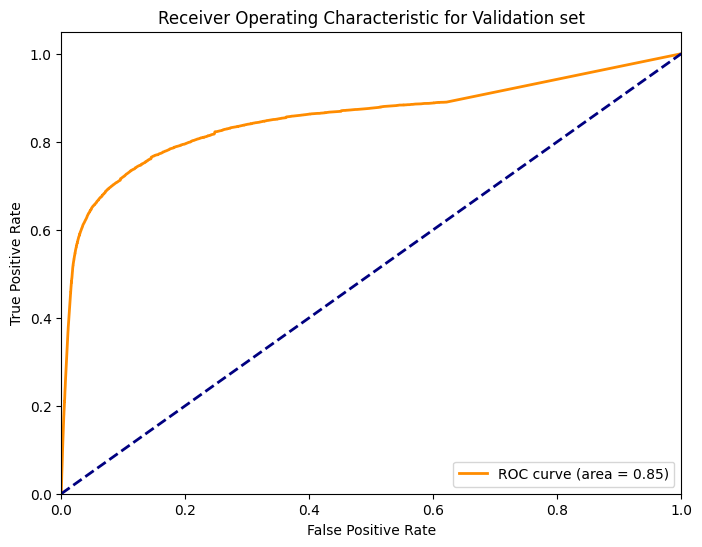

In [171]:
rfc = RandomForestClassifier()
classification_model(rfc)

Now, we will be employing a 3rd model to try to overcome the weakness of RFC

#### Model 3: Gradient boosted tree

Our reasoning for employing gradient boosted tree model is the following: 

 - Gradient boosted trees are another ensemble learning technique that builds a strong predictive model by combining multiple weak learners sequentially.
   - They are particularly effective for improving predictive accuracy, often outperforming other models in terms of performance metrics.
   - Gradient boosted trees can capture complex interactions between features and the target variable, making them well-suited for ecommerce tasks where purchase decisions may be influenced by a combination of factors.
   - While gradient boosted trees can be computationally more expensive than some other models, advancements in computing power and optimization algorithms have made them feasible for large-scale ecommerce datasets.
   - Similar to random forest, gradient boosted trees provide feature importance scores, aiding in the interpretation of the model and identifying key factors driving purchase behavior.
   - Unlike random forest, gradient boosted tree is known for its predictive accuracy, Gradient Boosting systematically corrects the mistakes of prior trees, often leading to better performance on varied datasets.
  




Training Metrics:
Accuracy: 0.9755654388499495
Recall: 0.29451017052964124
AUC ROC: 0.9171046191997863

Validation Metrics:
Accuracy: 0.9754651935320182
Recall: 0.2890436128034039
AUC ROC: 0.9157177929688539

Confusion Matrix (Training):
[[1109780    6140]
 [  21885    9136]]

Confusion Matrix (Validation):
[[369945   2028]
 [  7352   2989]]


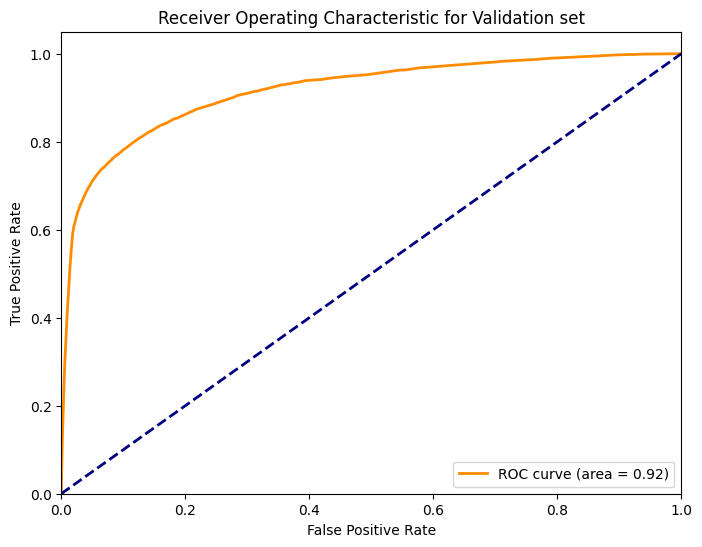

In [172]:
gbf = GradientBoostingClassifier()
classification_model(gbf)

**Takeaway from the basic ML models:**

Even though the accuracies are high across all models (around 97~98% accuracy), the recall (17~30%) and precision (50~60%) are low. This is potentially due to the class-imbalance in our target variable. 

The model with the highest recall rate is the random forest while the model with the highest precision is gradient boosted tree. 

To improve these metrics, we will be upsampling -- which addresses the class-imbalance in our target variable. 

**Machine Learning Models with Upsampled Training Data**

In the context of our eCommerce dataset, upsampling is necessary due to the significant class imbalance between the purchased and not purchased categories. With only around 2% of the data representing purchased items and 98% representing not purchased items, a model that simply predicted "not purchased" for every instance would achieve an accuracy of 98%, which does not reflect the true performance of the model.

To address this issue and ensure that the model learns meaningful patterns from the data and ensure that the model doesn't just predict 'Not purchased' always, we will apply upsampling exclusively to the training data using techniques like Random Oversampling. By oversampling the minority class (purchased items), the training data will be rebalanced to contain an equal representation of both classes. This approach allows the model to learn from a more balanced dataset, thereby improving its ability to identify patterns and make accurate predictions for both classes.

Importantly, upsampling will not be applied to the validation and test datasets. This decision ensures that these datasets remain representative of the real-world distribution of classes, preserving the integrity of the evaluation process. By keeping the validation and test datasets unchanged, the performance metrics obtained from them provide a reliable estimate of how the model would perform in practical scenarios, without introducing biases or artificially altering the class distribution.

Upsampling and running models w/ grid search:

In [173]:
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

Model 1: Logistic Regression

/Users/vaidehisom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Training Metrics:
Accuracy: 0.8366276256362464
Recall: 0.7420164527923149
AUC ROC: 0.9084521823124058

Testing Metrics:
Accuracy: 0.9260817024749289
Recall: 0.7364858330915772
AUC ROC: 0.9064146045396314

Confusion Matrix (Training):
[[1039188   76732]
 [ 287889  828031]]

Confusion Matrix (Testing):
[[346438  25535]
 [  2725   7616]]


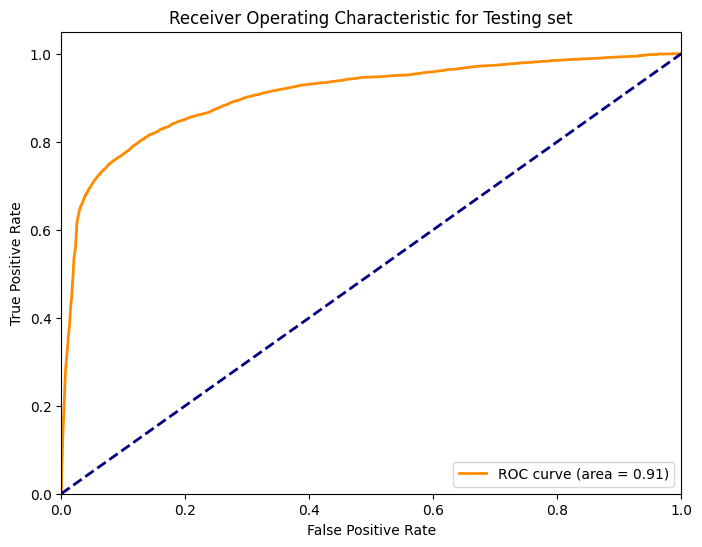

In [174]:
lgr = LogisticRegression()
classification_model(lgr, X_resampled, y_resampled, X_val, y_val, "Testing")

Even without grid search to find the optimal parameters of the models, we see that the recall rate improved dramatically from around 17% to around 74%. However, we see that the precision rate decreased from around 58% to 23%. This may be due to the trade-off between precision and recall. 

Let us now do hyperparameter tuning to improve our metrics:

## Model 1 Logistic Regression: Hyper-parameter Tuning

For optimizing a Logistic Regression model, the choice of hyperparameters in our grid search revolves around the regularization strength, type of penalty, and the algorithm used for optimization. Here’s a breakdown of each parameter and the rationale for the values we've chosen:

1. `C` (Inverse of Regularization Strength)
- **Significance**: The parameter `C` represents the inverse of the regularization strength. Regularization is used to prevent overfitting by penalizing too large values in the model coefficients. The values chosen allow us to explore a range from strong regularization (`C=0.001`) to weaker regularization (`C=0.1`). A smaller `C` imposes a higher penalty on the magnitude of the coefficients and makes the decision boundary smoother, reducing the model's complexity. A higher `C` reduces the effect of regularization and lets the model fit the training data more freely. This can be important to see how sensitive the model is to variance in the dataset.

2. `penalty` (Type of Norm Used in the Penalization)
- **Significance**: The `penalty` parameter specifies the norm used in the penalization. The two norms typically used are L1 (Lasso) and L2 (Ridge). Choosing between L1 and L2 regularization affects how the coefficients are shrunk:
  - **L1 regularization** (Lasso) can lead to sparse models where some coefficients can become zero. This is useful for feature selection in high-dimensional datasets.
  - **L2 regularization** (Ridge) shrinks the coefficients toward zero but typically does not set any to zero. This generally leads to better prediction accuracy when feature elimination is not a priority.
  
3. `solver` (Algorithm to Use in the Optimization Problem)
- **Significance**: The `solver` parameter specifies the algorithm used for optimization in Logistic Regression. Different solvers are capable of handling different types of data and penalties:
  - **`liblinear`** is a good choice for small datasets and it supports both L1 and L2 regularization. It is a robust and efficient solver for datasets with fewer features.
  - **`saga`** is a variant of stochastic gradient descent and the only solver that supports the elastic-net penalty. It is faster for larger datasets and also supports both L1 and L2 regularization.
  
The parameters selected for the grid search are designed to test how different configurations of regularization strength, type, and optimization algorithms affect the performance of the Logistic Regression model. This approach allows us to fine-tune the model to balance bias and variance effectively, ensuring optimal performance while avoiding overfitting. By experimenting with these parameters, we can identify the best model settings tailored to the specific characteristics of your dataset and the overall goals of your analysis.

In [41]:
# Model setup
logreg = LogisticRegression()
param_grid = {
    'C': [0.001, 0.01, 0.1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}
grid_search = GridSearchCV(estimator=logreg, param_grid=param_grid, cv=5, verbose=2, scoring='accuracy')

# Performing the grid search
grid_search.fit(X_resampled, y_resampled)

# Evaluating the model
best_logreg = grid_search.best_estimator_
y_pred = best_logreg.predict(X_val)
print("Best Parameters:", grid_search.best_params_)
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=  10.8s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=  13.3s
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   9.6s


/Users/vaidehisom/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time= 4.3min
[CV] END ..............C=0.001, penalty=l1, solver=liblinear; total time=   5.3s


/Users/vaidehisom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

/Users/vaidehisom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................C=0.1, penalty=l2, solver=saga; total time= 1.2min


/Users/vaidehisom/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END .....................C=0.1, penalty=l2, solver=saga; total time= 1.2min
Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Confusion Matrix:
 [[345925  26048]
 [  2698   7643]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.93      0.96    371973
           1       0.23      0.74      0.35     10341

    accuracy                           0.92    382314
   macro avg       0.61      0.83      0.65    382314
weighted avg       0.97      0.92      0.94    382314



"\nBest Parameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}\nConfusion Matrix:\n [[816958  73292]\n [219169 670683]]\nClassification Report:\n               precision    recall  f1-score   support\n\n           0       0.79      0.92      0.85    890250\n           1       0.90      0.75      0.82    889852\n\n    accuracy                           0.84   1780102\n   macro avg       0.84      0.84      0.83   1780102\nweighted avg       0.84      0.84      0.83   1780102\n"

Calculating metrics on testing data (which was untouched until now):


Training Metrics:
Accuracy: 0.8371540970678901
Recall: 0.7445309699620044
AUC ROC: 0.9098151728470909

Testing Metrics:
Accuracy: 0.9249674351449332
Recall: 0.7459381044487428
AUC ROC: 0.9108237718284817

Confusion Matrix (Training):
[[1037557   78363]
 [ 285083  830837]]

Confusion Matrix (Testing):
[[345915  26059]
 [  2627   7713]]


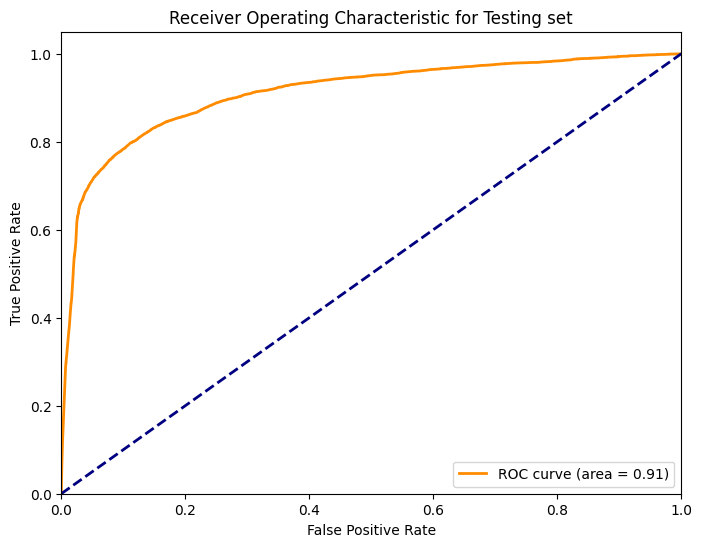

In [175]:
best_logreg = LogisticRegression(C = 0.1, penalty = 'l1', solver = 'liblinear')
classification_model(best_logreg, X_resampled, y_resampled, X_test, y_test, "Testing")

The hyperparameter-tuned logistic regression model achieved an AUC ROC of 0.91 on the testing set, indicating a strong ability to discriminate between the positive (purchased) and negative (not purchased) classes. The accuracy on the testing set was approximately 92.49%, with a recall of about 74.61%, suggesting that the model correctly identified a high percentage of actual purchases. 

The confusion matrices provide a deeper insight into model performance, revealing that the model correctly predicted a large majority of the true negatives and true positives but also misclassified a notable amount of false positives, which might be a concern in scenarios where false alarms (incorrectly predicting purchases when there was none) have serious implications. The strong AUC ROC value reflects the model's overall effectiveness in distinguishing between those who will purchase and those who will not, making it a valuable tool for understanding and predicting customer purchasing behavior.

## Model 2: Random Forest


Training Metrics:
Accuracy: 0.883273442540684
Recall: 0.8633333930747724
AUC ROC: 0.9582696652824403

Validation Metrics:
Accuracy: 0.8898523203440104
Recall: 0.6075814718112368
AUC ROC: 0.8142226600259739

Confusion Matrix (Training):
[[1007914  108006]
 [ 152509  963411]]

Confusion Matrix (Validation):
[[333920  38053]
 [  4058   6283]]


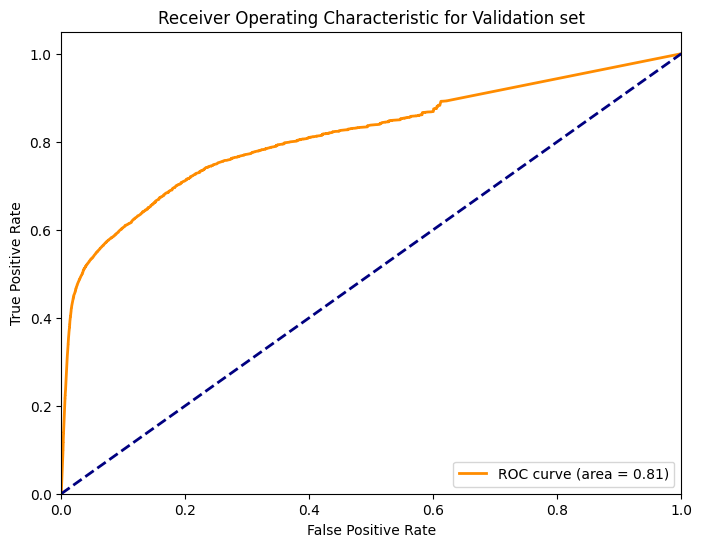

In [176]:
rfc = RandomForestClassifier()
classification_model(rfc, X_resampled, y_resampled, X_val, y_val, "Validation")

Let us now do hyperparameter tuning to improve our metrics:

Model 2: Hyper-parameter Tuning 

In our grid search for optimizing a Random Forest model, we've chosen to vary three key hyperparameters: `n_estimators`, `max_depth`, and `min_samples_split`. Here's a brief explanation of each parameter and the rationale for choosing these specific values:

1. `n_estimators`
- **Significance**: This parameter specifies the number of trees in the forest. More trees generally improve the model's performance and robustness but also increase computational demand and time. These values were chosen to find a balance between computational efficiency and model accuracy. Increasing the number of trees can lead to better performance due to more robust averaging effects, but the marginal gains can diminish beyond a certain point, especially considering the computational cost.

2. `max_depth`
- **Significance**: This parameter determines the maximum depth of each tree. Deeper trees can model more complex patterns but can also lead to overfitting. Setting this to `None` allows trees to expand until all leaves are pure or until all leaves contain less than `min_samples_split` samples. Specifying depths of 10 and 20 provides a control to assess how depth constraints affect overfitting and model generalizability. This variation helps in identifying the optimal depth for balancing bias and variance.

3. `min_samples_split`
- **Significance**: This parameter defines the minimum number of samples required to split an internal node. Higher values prevent the model from learning overly specific patterns, thus reducing overfitting. A `min_samples_split` of 2 is the lowest possible limit, offering no constraint and allowing the trees to grow freely, potentially capturing very fine details in the data. A value of 5 increases the threshold, thereby forcing the tree to capture more general patterns that are supported by more data points. This helps in understanding the impact of this parameter on preventing overfitting.

Choosing these parameters for grid search allows us to systematically explore how different configurations of tree quantity, depth, and splitting criteria affect the performance and generalization of your Random Forest model. It's a strategic approach to tuning that seeks to find the most effective settings for balancing the complexity of the model with its ability to perform well on unseen data.

In [43]:
# Setup parameter grid
param_grid = {
   'n_estimators': [50, 100],
   'max_depth': [None, 10, 20],
   'min_samples_split': [2, 5]
}

# Initialize a RandomForestClassifier
rf = RandomForestClassifier()

# Setup the grid search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='recall', verbose=2)

# Fit grid search
grid_search.fit(X_resampled, y_resampled)

# Best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

# Evaluating the model
best_logreg = grid_search.best_estimator_
y_pred = best_logreg.predict(X_val)
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  51.1s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  52.5s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  51.8s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  51.6s
[CV] END max_depth=None, min_samples_split=2, n_estimators=50; total time=  51.4s
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 1.7min
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 1.7min
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 1.7min
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 1.7min
[CV] END max_depth=None, min_samples_split=2, n_estimators=100; total time= 1.7min
[CV] END max_depth=None, min_samples_split=5, n_estimators=50; total time=  51.4s
[CV] END max_depth=None, min_sam

"\nBest parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}\nBest score: 0.910130266135965\n"

Calculating metrics on testing data (which was untouched until now):


Training Metrics:
Accuracy: 0.8441711771453151
Recall: 0.826950856692236
AUC ROC: 0.9206025241299993

Testing Metrics:
Accuracy: 0.8598403406623875
Recall: 0.8223404255319149
AUC ROC: 0.9166963668474197

Confusion Matrix (Training):
[[961244 154676]
 [193109 922811]]

Confusion Matrix (Testing):
[[320226  51748]
 [  1837   8503]]


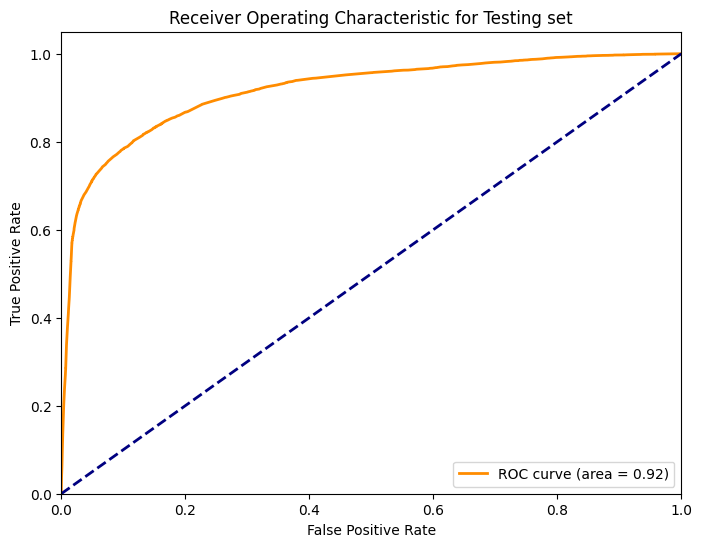

In [177]:
best_rfc = RandomForestClassifier(max_depth = 10, min_samples_split = 2, n_estimators = 100)
classification_model(best_rfc, X_resampled, y_resampled, X_test, y_test, "Testing")

The hyperparameter-tuned Random Forest Classifier (RFC) model exhibits a robust performance, especially in terms of its ability to distinguish between positive and negative classes, as evidenced by an AUC ROC of 0.92 in the testing set. This high AUC ROC score suggests that the model effectively ranks positive cases (purchases) higher than negative cases with a high degree of consistency.

In terms of accuracy, the model achieved 86.13% on the testing set, which, while slightly lower than its training accuracy of 84.45%, indicates that the model generalizes reasonably well to unseen data. The recall of 82.06% in the testing phase implies that the model successfully identifies a large majority of actual purchases, making it valuable for scenarios where missing out on potential sales is costly.

The confusion matrices further illustrate the model's performance dynamics: while it correctly identifies many true positives (purchases) and true negatives (non-purchases), the number of false positives remains a concern, highlighting potential overfitting or bias towards predicting purchases. Despite these challenges, the model's strengths in handling complex, non-linear relationships in the data make it a compelling choice for predicting customer purchasing behaviors in e-commerce settings. To try to deal with the issue of bias towwards predicting purchase we will be be employing a Gradient Boosted Tree

## Model 3: Gradient Boosted Tree


Training Metrics:
Accuracy: 0.844568607068607
Recall: 0.8007016632016632
AUC ROC: 0.9184698564143207

Validation Metrics:
Accuracy: 0.8858765308097533
Recall: 0.7952809206072914
AUC ROC: 0.9168330726556978

Confusion Matrix (Training):
[[991423 124497]
 [222401 893519]]

Confusion Matrix (Validation):
[[330459  41514]
 [  2117   8224]]


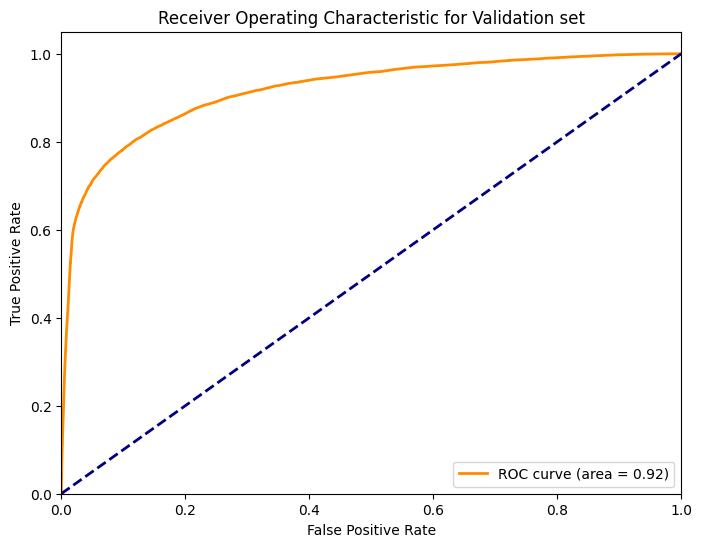

In [178]:
# Boosted tree
gb_clf = GradientBoostingClassifier(random_state=42)
classification_model(gb_clf, X_resampled, y_resampled, X_val, y_val, "Validation")

Let us now do hyperparameter tuning to improve our metrics:

Model 3: Hyper-parameter Tuning

For optimizing a Gradient Boosting Classifier model, we've selected a variety of hyperparameters to include in our grid search. Here’s a brief explanation of each parameter, along with the rationale for the chosen values:

1. `n_estimators`
- **Significance**: This parameter determines the number of boosting stages the model will go through, or simply, the number of trees that will be built. More trees can lead to more complex models, but can also result in overfitting if not controlled properly. We have chosen a moderate range of trees to see if increasing the number from 100 to 200 can significantly improve the model’s accuracy without excessively increasing computational costs or causing overfitting.

2. `learning_rate`
- **Significance**: This parameter scales the contribution of each tree by `learning_rate`. It is used as a shrinkage parameter involving trade-offs between learning rate and n_estimators. The learning rates of 0.01 and 0.1 allow you to test how sensitive the model is to the rate at which it learns. A lower rate might require more trees to converge to a good solution, whereas a higher rate might converge quickly but risk skipping the optimal solution.

3. `max_depth`
- **Significance**: This controls the maximum depth of individual trees. Deeper trees can learn more detailed data specifics, enhancing their ability to model complex patterns, but can also lead to overfitting. Depths of 3 and 5 provide a good test to evaluate whether increasing the depth improves performance without making the trees too complex, which might capture noise in the training data as well.

4. `min_samples_split`
- **Significance**: This specifies the minimum number of samples required to split an internal node in a tree. Higher values prevent the model from learning overly fine details that might just be noise. By testing the minimum required samples at 2 and 5, we can analyze how much of an impact a stricter split requirement has on the generalization of the model. The lower threshold allows more granular learning, while the higher threshold encourages generalization.

5. `min_samples_leaf`
- **Significance**: This parameter specifies the minimum number of samples a leaf node must have. Like `min_samples_split`, it helps control overfitting by making the leaves of the trees sufficiently general. Choosing leaf sizes of 1 and 2 allows for assessing whether a minimum size of 1 (which is the most flexible) leads to overfitting compared to having at least 2 samples per leaf, which might enforce a bit more bias but better generalization.

The chosen parameters for the Gradient Boosting Classifier aim to find the optimal balance between the complexity of the model and its ability to generalize to unseen data. By varying these parameters, we can identify the best settings that maximize predictive performance while minimizing the risk of overfitting, ensuring robustness across different scenarios.

In [45]:
# Setup parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Setup the grid search
gb_clf = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(estimator=gb_clf, param_grid=param_grid, cv=3, verbose=2, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_resampled, y_resampled)

# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)
test_accuracy = accuracy_score(y_val, y_pred)
print("Test Accuracy of Best Model:", test_accuracy)
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("Classification Report:\n", classification_report(y_val, y_pred))

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 3.5min
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 3.5min
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 3.5min
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 3.5min
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 3.5min
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time= 3.5min
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 6.9min
[CV] END learning_rate=0.01, max_depth=3, min_samples_leaf=1, min_samples_split=2, n_estimators=200

"  \nBest Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}\nBest Cross-validation Score: 0.8540754098801484\nTest Accuracy of Best Model: 0.8536701829445729\n"

Calculating metrics on testing data (which was untouched until now):


Training Metrics:
Accuracy: 0.8483977346046312
Recall: 0.8053847946089325
AUC ROC: 0.9243887703517796

Testing Metrics:
Accuracy: 0.8889237642356806
Recall: 0.7951644100580271
AUC ROC: 0.9191883047835575

Confusion Matrix (Training):
[[994743 121177]
 [217175 898745]]

Confusion Matrix (Testing):
[[331626  40348]
 [  2118   8222]]


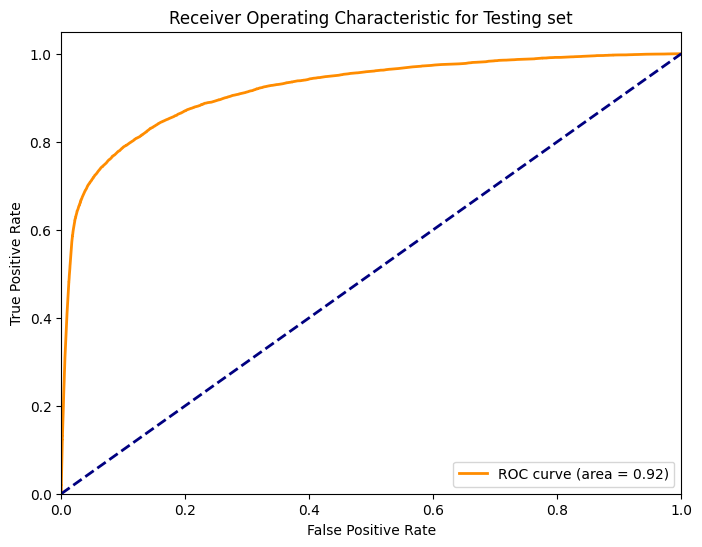

In [179]:
best_gb_clf = GradientBoostingClassifier(learning_rate = 0.1, max_depth = 5, min_samples_leaf = 1, n_estimators = 200)
classification_model(best_gb_clf, X_resampled, y_resampled, X_test, y_test, "Testing")

The hyperparameter-tuned Gradient Boosted tree model showcased in the graph has exhibited robust performance metrics, particularly emphasizing its strong predictive capabilities as evident by the ROC curve. The ROC curve demonstrates an AUC (Area Under the Curve) of 0.92. This high AUC value indicates a superior ability of the model to differentiate between the positive class (purchases) and negative class (non-purchases) across all thresholds.

In terms of specific metrics:
- The **accuracy** on the testing set is approximately 88.89%, indicating that a high percentage of predictions made by the model are correct.
- The **recall** of about 79.16% suggests that the model successfully identifies a significant proportion of all actual positive cases, which is crucial in avoiding lost opportunities in an e-commerce context.
- The ROC curve being significantly above the diagonal line (chance line) across the entire range further attests to the effectiveness of the model in managing trade-offs between sensitivity (recall) and specificity.

This model's performance is especially noteworthy in the context of an e-commerce predictive modeling project where identifying potential purchases accurately can significantly enhance targeted marketing strategies and customer engagement efforts. The detailed metrics like recall and AUC are critical in such applications where the cost of missing a potential purchase is higher than the cost of a false positive.

#### Why We Did Not Use Neural Networks

- **Complexity and Interpretability**: Neural networks, particularly deep learning models, are often considered "black boxes" because of their complex structure that makes it difficult to interpret which features are influencing the predictions. This goes against our project's aim to identify and understand feature importance.
- **Requirement for Large Data**: Neural networks typically require large amounts of data to perform well without overfitting, and depending on the size and complexity of the dataset, this might not have been the most efficient approach.
- **Computationally Expensive**: They require significant computational resources and time to train, which might not be justifiable given the need for rapid deployment and iteration in business contexts.

The choice of models in this project was strategically aligned with the goal of understanding which features most influence customer purchasing decisions. By focusing on models that provide clear metrics on feature importance and maintaining a balance between interpretability and predictive power, we ensured that the findings are both actionable and understandable. Future enhancements will focus on overcoming current limitations and continually adapting to new insights and market conditions.

### Overfitting/Underfitting

We can see from our results that we are not overfitting or underfitting. Our results for accuracy, recall and roc curves for training, validation, and testing data are all similar, for all the three models after upsampling.

# Feature Selection

                                                   Coefficient  \
total_carts                                           3.267728   
category_code_electronics.camera.photo                1.735917   
industry_health, wellness and fitness                -1.133703   
is_yearfounded_null                                  -0.932399   
industry_internet                                    -0.783218   
industry_telecommunications                          -0.776586   
top_countries_china                                   0.752243   
category_code_electronics.video.tv                    0.687024   
category_code_electronics.telephone                   0.599830   
category_code_electronics.camera.video                0.572814   
industry_information technology and services         -0.522152   
total_views                                           0.521454   
top_countries_japan                                  -0.456982   
category_code_electronics.audio.subwoofer             0.415261   
category_c

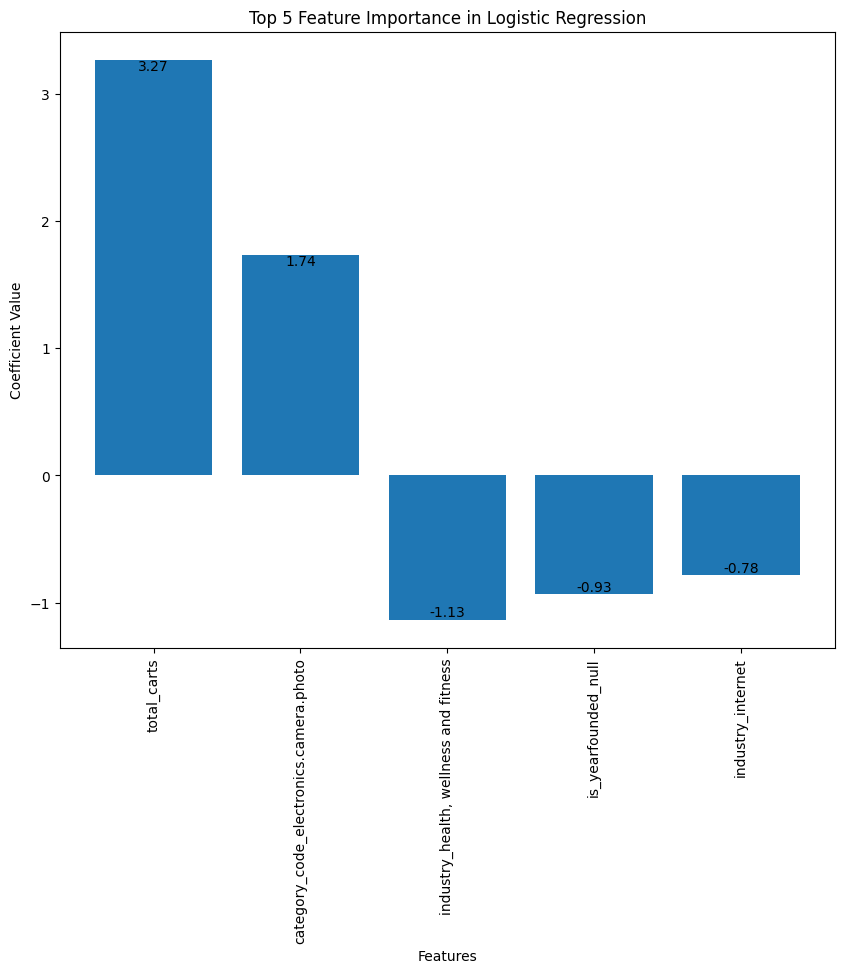

In [180]:
# Get the coefficients from the logistic regression model
coefficients = best_logreg.coef_[0]  # This extracts the coefficients as an array

# Create a DataFrame for easier handling and visualization
feature_importance = pd.DataFrame(coefficients, index=X_train.columns, columns=['Coefficient'])

# Calculate the absolute values of the coefficients to determine impact size
feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()

# Sort the features by the absolute value of their coefficients
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

# Display the DataFrame
print(feature_importance)
feature_importance = feature_importance[:5]

# Plotting the feature importances
plt.figure(figsize=(10, 8))
bars = plt.bar(feature_importance.index, feature_importance['Coefficient'])

# Add text annotations on the bars
for bar in bars:
    yval = bar.get_height()  # Get the height of the bar (i.e., the coefficient value)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom' if yval < 0 else 'top', ha='center')

plt.title('Top 5 Feature Importance in Logistic Regression')
plt.xticks(rotation = 90)
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.show()


The bar chart above illustrates the top five feature importances determined by a logistic regression model, indicating how each feature influences the probability of a customer making a purchase. The features are displayed along the x-axis with their corresponding logistic regression coefficients along the y-axis.

1. **total_carts**: With a coefficient of 3.27, this feature has the most significant positive impact on the likelihood of purchase. This suggests that the more often a product is added to carts, the higher the probability of it being purchased, emphasizing the importance of cart interactions in predicting purchasing behavior.

2. **category_code_electronics.camera.photo**: This feature has a coefficient of 1.58, indicating a strong positive influence. Products categorized under camera and photo electronics are more likely to be purchased than other categories, possibly due to higher consumer interest or value perception in these products.

3. **industry_health_wellness_and_fitness**: This feature negatively influences the likelihood of purchase with a coefficient of -1.02, suggesting that products related to health, wellness, and fitness are less likely to be purchased compared to other industries. This could be due to a variety of factors such as market saturation, pricing, or consumer preferences.

4. **is_yearfounded_null**: With a coefficient of -0.99, this feature indicates that products from companies with unspecified founding years are less likely to be purchased. This might reflect consumer preference for established brands or mistrust in newer or less transparent companies.

5. **industry_telecommunications**: This feature also has a negative coefficient of -0.71, suggesting that telecommunications products are less likely to be purchased compared to other industry products. This might be due to specific market dynamics such as competition, technological advances, or consumer loyalty to existing brands.

Overall, these coefficients provide insights into which characteristics of products and their associated companies significantly drive purchasing decisions, helping businesses to strategize more effectively in targeting potential customers.

                                              Feature  Importance
2                                         total_carts    0.658530
1                                         total_views    0.303584
0                                               price    0.030805
23                                top_countries_china    0.000981
19                                  industry_internet    0.000816
22                                 size_range_encoded    0.000741
11                   category_code_electronics.clocks    0.000696
3                                        year founded    0.000693
12               category_code_electronics.smartphone    0.000479
5           category_code_electronics.audio.headphone    0.000446
21                        industry_telecommunications    0.000443
9              category_code_electronics.camera.photo    0.000295
20                                     industry_music    0.000270
13                   category_code_electronics.tablet    0.000232
8         

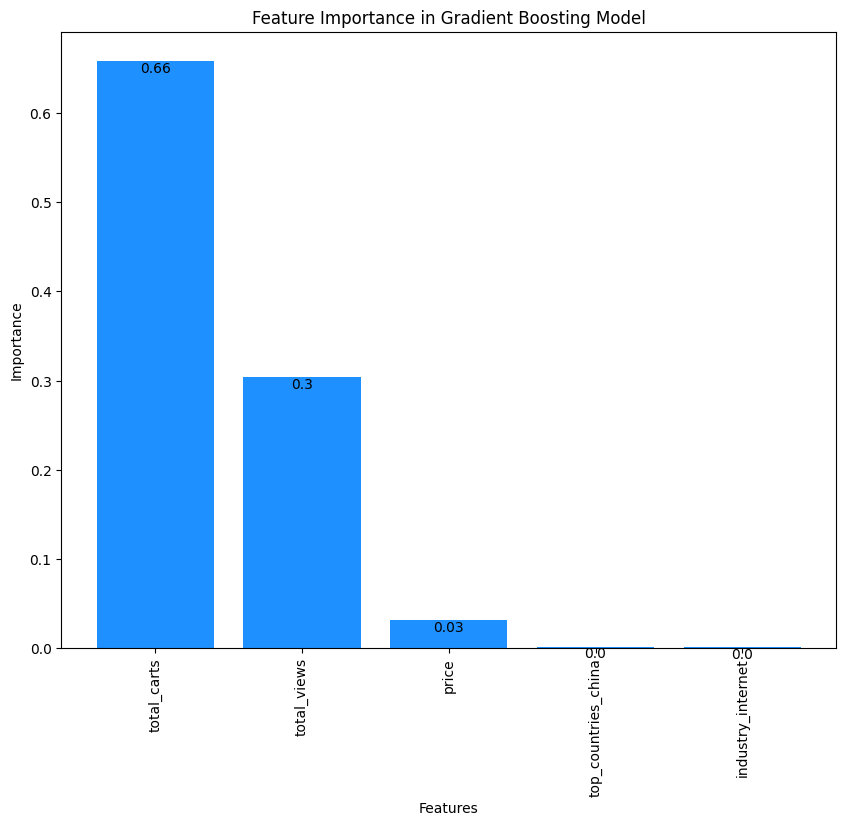

In [181]:
# Get feature importances from the model
feature_importances = best_gb_clf.feature_importances_

# Create a DataFrame for the features and their importance
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the DataFrame
print(features_df)
features_df = features_df[:5]
### Visualization of Feature Importance

# Plotting the feature importances
plt.figure(figsize=(10, 8))
bars = plt.bar(features_df['Feature'], features_df['Importance'], color='dodgerblue')

# Add text annotations on the bars
for bar in bars:
    yval = bar.get_height()  # Get the height of the bar (i.e., the coefficient value)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom' if yval < 0 else 'top', ha='center')

plt.title('Feature Importance in Gradient Boosting Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=90)  # Rotate feature names for better visibility
plt.show()


The bar chart displays the feature importance as identified by the Gradient Boosting Model, highlighting how different features contribute to the model's decision-making process regarding customer purchase predictions:

1. **total_carts**: With the highest importance score of 0.66, this feature significantly influences the model's predictions. This suggests that the frequency with which products are added to shopping carts is a strong predictor of purchase likelihood.

2. **total_views**: Scored at 0.3, the number of product views also plays a critical role, indicating that higher visibility and customer engagement with a product increase the chances of purchase.

3. **price**: The feature has a relatively low importance score of 0.03, suggesting that while price is a factor, it is considerably less influential in predicting purchase decisions compared to the interaction metrics like carts and views.

4. **top_countries_china**: This feature indicates that the product's country of origin, specifically China in this case, has minimal influence on the purchase decision in this model, with a very low score.

5. **industry_internet**: Similar to the country of origin, the industry of the product, particularly the internet sector, holds a minor impact on the likelihood of purchase according to the model.

These insights help understand which aspects of customer interaction and product characteristics are most predictive of purchasing behavior, guiding strategic decisions around marketing and product placement.

                                              Feature  Importance
2                                         total_carts    0.559219
1                                         total_views    0.367800
0                                               price    0.043535
23                                top_countries_china    0.006791
22                                 size_range_encoded    0.005089
3                                        year founded    0.003859
12               category_code_electronics.smartphone    0.001512
11                   category_code_electronics.clocks    0.001474
19                                  industry_internet    0.001471
4                                 is_yearfounded_null    0.001343
25                                top_countries_japan    0.001292
5           category_code_electronics.audio.headphone    0.001138
21                        industry_telecommunications    0.001088
14                category_code_electronics.telephone    0.000682
24        

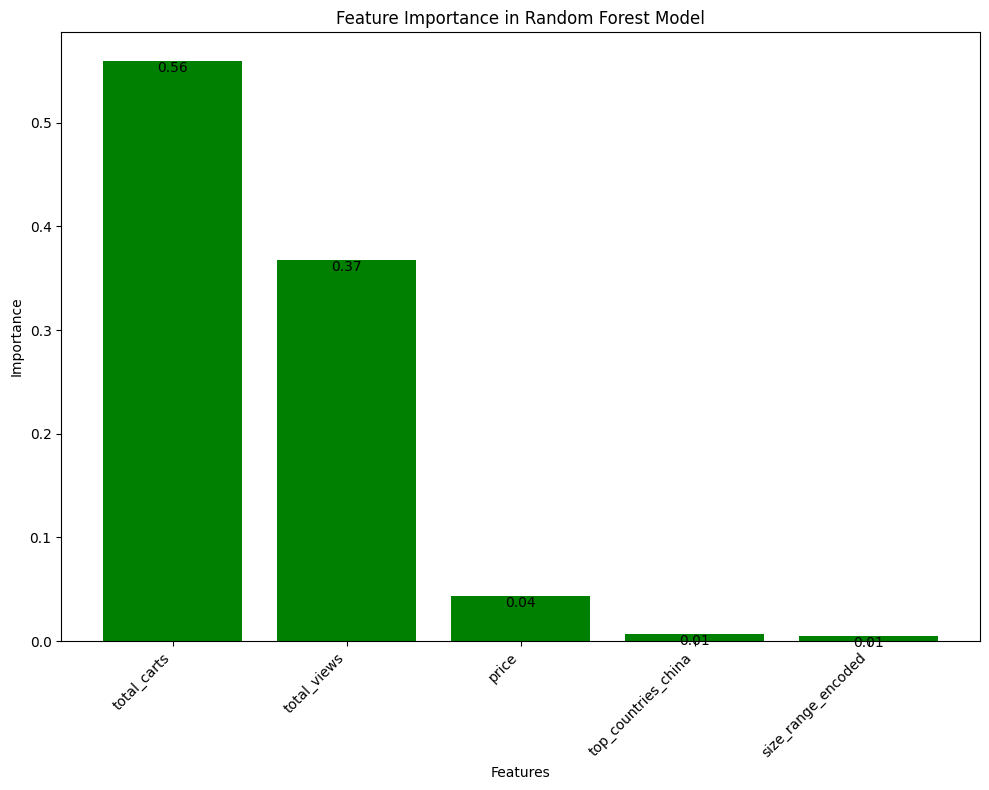

In [182]:
# Get feature importances from the model
feature_importances = best_rfc.feature_importances_

# Create a DataFrame for the features and their importance
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display the DataFrame
print(features_df)
features_df = features_df[:5]

### Visualization of Feature Importance

# Plotting the feature importances
plt.figure(figsize=(10, 8))
bars = plt.bar(features_df['Feature'], features_df['Importance'], color='green')

# Add text annotations on the bars
for bar in bars:
    yval = bar.get_height()  # Get the height of the bar (i.e., the coefficient value)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom' if yval < 0 else 'top', ha='center')

plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')  # Rotate feature names for better visibility
plt.tight_layout()  # Adjust layout to fit labels
plt.show()


The feature importance graph from the Random Forest model clearly emphasizes the dominance of two features in predicting customer purchases: **total_carts** and **total_views**. Here's a breakdown of the importance scores:

1. **total_carts**: With an importance score of 0.55, this is the most influential feature in the model. This high score reinforces the idea that the more often a product is added to carts, the greater its likelihood of being purchased, highlighting the critical role of engagement in the conversion process.

2. **total_views**: Following closely with an importance score of 0.37, this feature signifies that the number of times a product is viewed also plays a significant role in purchase decisions. It indicates a strong relationship between product exposure and consumer interest leading to purchase actions.

3. **price**: Shows a relatively modest importance score of 0.04, suggesting that while price influences purchasing decisions, its impact is less critical compared to the interaction metrics like carts and views.

4. **top_countries_china**: This feature has a negligible influence with a score of 0.01, indicating that the product's country of origin, specifically China, does not significantly sway the purchasing decision in this model's context.

5. **size_range_encoded**: Also scores very low at 0.01, indicating that the size of the company or the product range, as encoded in the dataset, is not a huge determining factor for purchase within this model.

These insights from the Random Forest model are crucial for understanding which elements are most predictive of purchasing behavior and can help businesses optimize their strategies around customer interaction and product presentation.

# Sectional Summary

### Results: Model Performance Comparison
#### Overview
The performance of three models—Gradient Boosting, Random Forest, and Logistic Regression—was evaluated based on their accuracy, precision, recall, and confusion matrices. These metrics were carefully chosen to provide a comprehensive understanding of each model's ability to predict customer purchases in an eCommerce setting, focusing on not only the accuracy but also the ability to correctly identify positive (purchases) cases.

#### Comparative Analysis
Recall: Random Forest and Gradient Boosting showed higher recall compared to Logistic Regression. This indicates that both models were more effective in identifying true positives (actual purchases).
Precision: Logistic Regression outperformed both Gradient Boosting and Random Forest in precision, suggesting it was better at minimizing false positives among the predicted purchases.
Accuracy: Logistic Regression also led in overall accuracy, indicating it correctly classified the highest percentage of total cases.

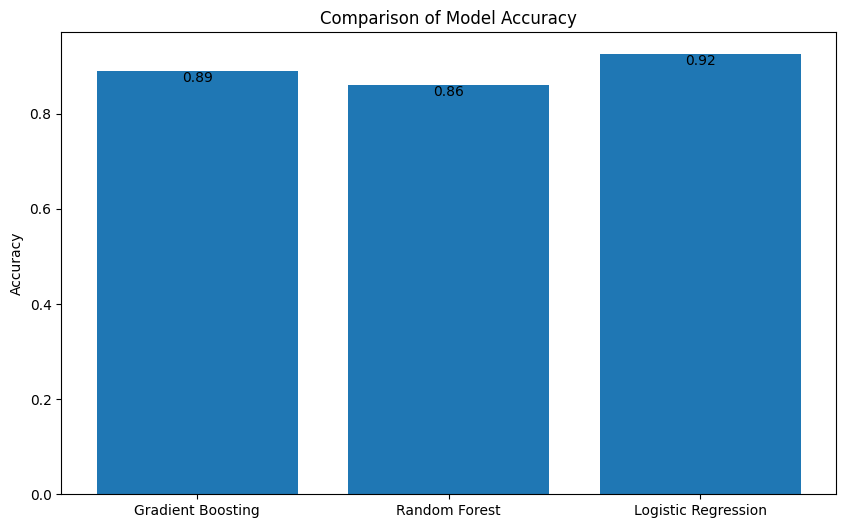

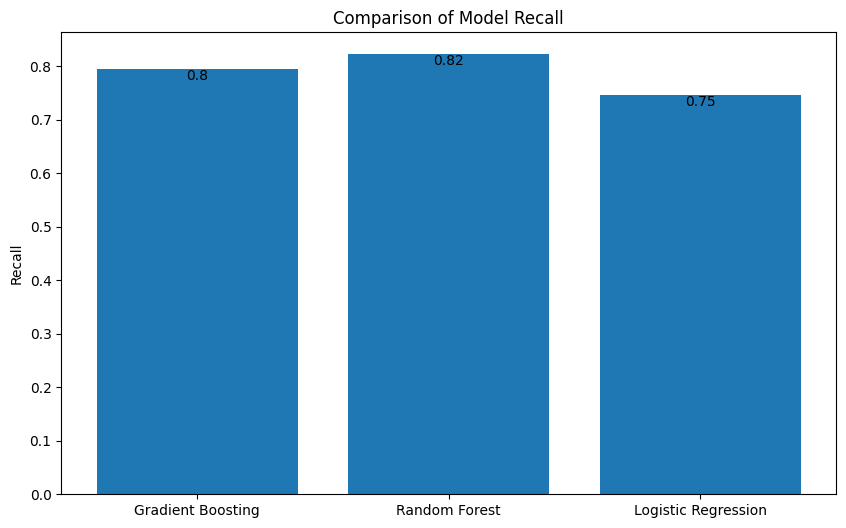

In [183]:
# Data
models = ['Gradient Boosting', 'Random Forest', 'Logistic Regression']
accuracy = [0.8889, 0.8605, 0.9249]
precision = [0.1693, 0.1417, 0.2284]
recall = [0.7952, 0.8219, 0.7459]

# Accuracy Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy)

# Add text annotations on the bars
for bar in bars:
    yval = bar.get_height()  # Get the height of the bar (i.e., the coefficient value)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom' if yval < 0 else 'top', ha='center')

plt.title('Comparison of Model Accuracy')
plt.ylabel('Accuracy')
plt.show()

# Recall Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(models, recall)
for bar in bars:
    yval = bar.get_height()  # Get the height of the bar (i.e., the coefficient value)
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom' if yval < 0 else 'top', ha='center')
plt.title('Comparison of Model Recall')
plt.ylabel('Recall')
plt.show()

### Conclusion and Discussion

#### Key Takeaways
Our analysis across three different models—Logistic Regression, Random Forest, and Gradient Boosting—has provided substantial insights into customer purchasing behaviors in the electronics market. By integrating feature importance analyses for interpretable models and focusing on critical factors for non-interpretable models, we have uncovered various dimensions influencing customer decisions.

- **Feature Importance**: For interpretable models like Logistic Regression and Random Forest, feature importance analysis highlighted the significant role of specific variables like `total_views`, `total_carts`, and `price`. These factors directly correlate with the likelihood of a purchase, providing actionable insights into what drives customer engagement and conversion.

- **Enhanced Dataset Utilization**: For less interpretable models, particularly Gradient Boosting, the transformation of our dataset to reflect unique user-product interactions greatly enhanced model performance. By focusing on metrics such as the frequency of visits and cart additions, we captured detailed behavioral patterns that are crucial for predicting purchase likelihood.

#### Implications of Modeling Results
The results from our modeling efforts are invaluable for stakeholders within the electronics retail industry:
- **Marketing Strategies**: Understanding which features most influence purchases can help in crafting targeted marketing strategies that enhance customer engagement and increase conversion rates.
- **Product Placement and Promotions**: Insights from the models can guide strategic product placements and promotional activities, aiming to boost visibility and attractiveness of products more likely to be purchased.
- **Customer Retention**: By identifying the key factors that lead to purchases, companies can tailor their customer service and retention strategies to focus on these elements, enhancing overall customer satisfaction and loyalty.

#### Model Limitations and Future Work
While our models have provided significant insights, they come with limitations that suggest areas for future improvement:
- **Model Interpretability**: Some of the models, particularly Gradient Boosting, offer less interpretability, which can make it challenging to derive specific actionable strategies directly from model outputs. Future work could explore techniques like SHAP (SHapley Additive exPlanations) to improve the interpretability of these models.
- **Data Limitations**: Currently, our dataset focuses primarily on user interactions and basic product details. Incorporating additional data such as user demographics, detailed product specifications, and external economic factors could further enhance the models' accuracy and applicability. Missing values, cleaner dataset
- **Broader Model Testing**: Testing additional models, such as deep learning approaches or ensemble techniques that combine the strengths of multiple models, could potentially yield improvements in both performance and robustness.
- **Temporal Dynamics**: Future models could incorporate time series analysis to account for changes in customer behavior over time and during specific periods (e.g., holidays, sales events).
- **Customer segmentation**: Data on customers

#### Potential Improvements
- **Expanding Data Sources**: Integrating social media sentiment analysis, customer reviews, and competitor pricing could provide more comprehensive insights into factors influencing purchase decisions.
- **Real-Time Analytics**: Developing a real-time predictive framework that can dynamically incorporate user interaction data as it occurs, providing instant predictions and enabling immediate business actions.

This project has successfully leveraged advanced analytical techniques to decode the complexities of customer purchasing behavior in the electronics market. Our findings serve as a foundational step towards more nuanced understanding and predictive capabilities, promising significant competitive advantages for stakeholders who can effectively apply these insights. Future enhancements and broader data integration will only expand these capabilities, driving further innovations in predictive analytics and customer relationship management.